In [5]:
#Figures, in order:
# Heatmap of shared Neanderthal and denisovan ancestry (if time, ancestry-aware sharing which would be supplemental) (MAIN FIG)
# Proportions of EUR admixture + sharing averages per AMR pops
# Recovered archaic ancestry per pop (Denisovan, Neand, total archaic)
# ancestry-specific recovered (MAIN FIG)
# simulations recovered (no need to invoke selection or anything)
# Shared archaic versus IBD (since emilia likes that plot IG) (MAIN FIG)
# Boxplots of IBD in each of the relevant pops for real data
# then boxplots of IBD in each of the relevant pops for sims (standard, not donor models; would expect more IBD in real data methinks)
# European vs IBD (include confidence intervals) (MAIN FIG)
# African vs IBD
# Indigenous vs IBD
# ancestry-specific PCA (needs fixing) (MAIN FIG)
# sims with donor model per admix pop
# sims with different models per MXL admixture props (MAIN FIG)
# mtDNA and Y haplogroup stuff

In [6]:
# Proportions of EUR admixture + sharing averages per AMR pops
# ancestry-specific PCA (needs fixing) (MAIN FIG)

# We start with overall sharing measures within and between all populations

## Here we have heatmaps + sharing amounts within each population

In [7]:
import gzip
import pandas as pd
import tarfile
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.ticker import FuncFormatter
import os

import numpy as np
from scipy import stats
import itertools
from mpl_toolkits.axes_grid1 import make_axes_locatable
import statistics
import re
from collections import defaultdict
from itertools import combinations
from scipy.stats import mannwhitneyu
from scipy.stats import linregress, spearmanr
import statsmodels.stats.multitest as smm
from statsmodels.stats.multitest import multipletests
import tskit
import statsmodels.api as sm
import pyranges as pr
import seaborn as sns
import statistics


In [5]:
### filtering laurits hmmix calls
hmmix = pd.read_csv('/users/akuntzle/IBD_archaic_shared/data/hmmix_output/hg38_1000g_segments.txt', sep=r"\s+")
hmmix[(hmmix['mean_prob'] >= 0.80) & (hmmix['ND_type'] == 'Neanderthal')].to_csv('/users/akuntzle/IBD_archaic_shared/data/hmmix_output/hmmix_neanderthal_filtered.csv',index=None)
hmmix[(hmmix['mean_prob'] >= 0.80) & (hmmix['ND_type'] == 'Denisova')].to_csv('/users/akuntzle/IBD_archaic_shared/data/hmmix_output/hmmix_denisovan_filtered.csv',index=None)
hmmix[(hmmix['mean_prob'] >= 0.80)].to_csv('/users/akuntzle/IBD_archaic_shared/data/hmmix_output/hmmix_filtered.csv',index=None)

In [6]:
sub_pops = ['CHB', 'JPT', 'CHS', 'CDX', 'KHV', #3000
            'CEU', 'TSI', 'GBR', 'FIN', 'IBS',  #2000
            'GIH', 'PJL', 'BEB', 'STU', 'ITU', #3000
            'MXL', 'PEL', 'PUR', 'CLM']

In [7]:
# To get pairwise intersections, run /users/akuntzle/IBD_archaic_shared/code/pairwise_all.script
# which uses pairwise_hmmix.sh and pairwise_within_hmmix.sh

In [8]:
def get_averages_list(filenames):
    all_integers = []
    total_no_share = 0

    for filename in filenames:
        with open(filename, 'r') as file:
            for line in file:
                line = line.strip().split()
                if len(line) < 3:
                    continue  # skip malformed lines

                id1, id2, num_intersect = line[0], line[1], int(line[2])

                if 'sorted' in id1 and 'sorted' in id2:
                    all_integers.append(num_intersect)
                    if num_intersect == 0:
                        total_no_share += 1

    if not all_integers:
        return 0, 0, 0, 0  # handle case where nothing matched

    nonzero = [x for x in all_integers if x > 0]
    avg_all = sum(all_integers) / len(all_integers)
    avg_cond_on_share = sum(nonzero) / len(nonzero) if nonzero else 0
    print(avg_all)

    return len(all_integers), avg_all, total_no_share, avg_cond_on_share


In [9]:
#returns # of pairs, average of all pairs, # of pairs that have no sharing, average of pairs conditioned on sharing
#currently only works for laurits's stuff - need to re-run the pairwise comparisons with the sorted files
def get_averages(filename):
    with open(filename, 'r') as file:
        integers = []
        no_share = 0
        for line in file:
            line = line.strip().split()
            id1 = line[0]
            id2 = line[1]
            if len(line) == 3:
                num_intersect = int(line[2])
            if 'sorted' in id1 and 'sorted' in id2:
                integers.append(num_intersect)
                if num_intersect == 0:
                    no_share += 1
        nonzero = [x for x in integers if x > 0]
        avg_cond_on_share = sum(nonzero) / len(nonzero) if nonzero else 0
        
        return len(integers), sum(integers)/len(integers), no_share, avg_cond_on_share
            

In [10]:
def get_comparisons(folder):
    compared_hmm = []
    dire = f"/users/akuntzle/data/akuntzle/hmmix_output/{folder}/"
    for i in range(len(sub_pops)):
        for j in range(i+1, len(sub_pops)):
            pot_path=f"{dire}{sub_pops[i]}_{{{sub_pops[j]}}}.txt"
            if os.path.isfile(pot_path):
                path = pot_path
            else:
                path = f"{dire}{sub_pops[j]}_{{{sub_pops[i]}}}.txt"
            with open(path, 'r') as file:
                num_pairs, total_avg, num_pairs_no_share, cond_avg = get_averages(path)
                compared_hmm.append(total_avg)
    
    # Create a dictionary for the pairwise comparison indices
    pairs = []
    for i in range(len(sub_pops)):
        for j in range(i + 1, len(sub_pops)):
            pairs.append((i, j))
            
    compared_hmm_2D = np.zeros((len(sub_pops), len(sub_pops)))
    
    for k, (i, j) in enumerate(pairs):
        compared_hmm_2D[i, j] = np.asarray(compared_hmm[k])
        compared_hmm_2D[j, i] = np.asarray(compared_hmm[k])
    
    for i in range(len(sub_pops)):
        diagonal_path = f"{dire}all_{sub_pops[i]}.txt"
        if os.path.isfile(diagonal_path):
            with open(diagonal_path, 'r') as file:
                num_pairs, total_avg, num_pairs_no_share, cond_avg = get_averages(diagonal_path)
                compared_hmm_2D[i, i] = float(total_avg)
    # print(compared_hmm_2D)
    return compared_hmm_2D

In [11]:
from matplotlib.ticker import ScalarFormatter

def plot_comparisons(compared_hmm_2D, min_val, max_val, archaic):
    fig, ax = plt.subplots()

    # Lower triangle mask
    lower_mask = np.tri(compared_hmm_2D.shape[0], compared_hmm_2D.shape[1], k=-1)
    upper_mask = lower_mask.T
    compared_hmm_2D_mask = np.ma.array(compared_hmm_2D, mask=upper_mask)

    # Use actual scale (important!)
    im = ax.imshow(compared_hmm_2D_mask, cmap='YlGn',
                   vmin=min_val, vmax=max_val)

    # Ticks
    ax.set_xticks(range(len(sub_pops)), labels=sub_pops,
                  rotation=45, ha="right", rotation_mode="anchor", fontsize=12)
    ax.set_yticks(range(len(sub_pops)), labels=sub_pops, fontsize=12)

        # Colorbar with scientific notation
    cbar = fig.colorbar(im, ax=ax)
    
    cbar.ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}×10⁶")
    )


    fig.tight_layout()

    plt.title(archaic, fontsize=16)
    plt.savefig(f'/users/akuntzle/IBD_archaic_shared/figures/{archaic}_shared_heatmap.png')


    for i in range(compared_hmm_2D.shape[0]):
        for j in range(compared_hmm_2D.shape[1]):
            # Skip masked (upper triangle)
            if not compared_hmm_2D_mask.mask[i, j]:
                x_label = sub_pops[j]
                y_label = sub_pops[i]
                val = compared_hmm_2D[i, j]
                
    plt.show()
    plt.close()

In [12]:
compared_hmm_nean = get_comparisons('pairwise_comparisons_neanderthal')
compared_hmm_den = get_comparisons('pairwise_comparisons_denisovan')

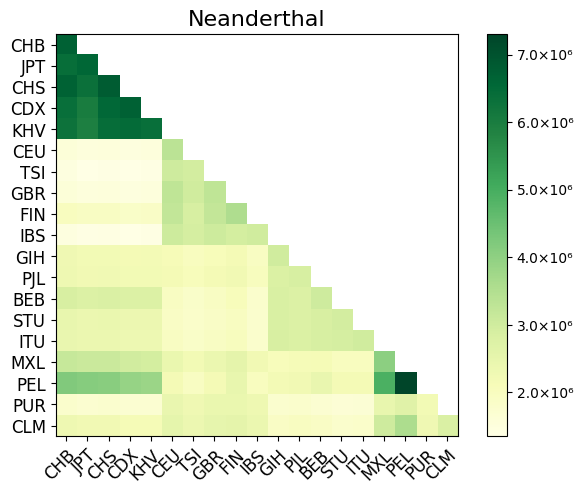

In [13]:
plot_comparisons(compared_hmm_nean, np.nanmin(compared_hmm_nean), np.nanmax(compared_hmm_nean), 'Neanderthal')

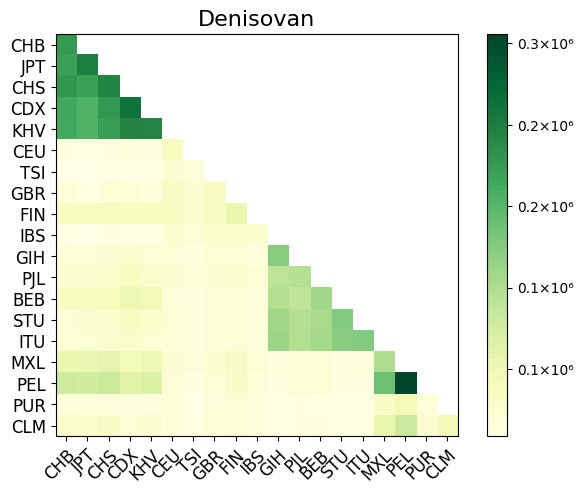

In [14]:
plot_comparisons(compared_hmm_den, np.nanmin(compared_hmm_den), np.nanmax(compared_hmm_den), 'Denisovan')

In [15]:
def summarize_pairwise_sharing(df, subpop_pair, exclude_zeros=False):
    vals = df[df['subpop_pair'] == subpop_pair]['value']
    
    if exclude_zeros:
        vals = vals[vals > 0]
    
    mean_val = np.mean(vals)
    std_val = np.std(vals, ddof=1)  # sample standard deviation
    
    # Convert to millions
    mean_million = mean_val / 1e6
    std_million = std_val / 1e6
    
    print(f"{subpop_pair}: {mean_million:.2f} ×10⁶ ± {std_million:.2f} ×10⁶")
    
    return mean_val, std_val

In [16]:
def get_distributions(archaic_type):
    input_dir = f"/users/akuntzle/data/akuntzle/hmmix_output/pairwise_comparisons_{archaic_type}"

    all_values = defaultdict(list)

    for fname in os.listdir(input_dir):
        filepath = os.path.join(input_dir, fname)

        # Match format like CLM_{ITU}.txt
        match_pairwise = re.match(r"^([A-Z]+)_\{([A-Z]+)\}\.txt$", fname)
        if match_pairwise:
            subpop1, subpop2 = match_pairwise.groups()
            pair_key = f"{subpop1}-{subpop2}"

            with open(filepath) as f:
                for line in f:
                    parts = line.strip().split("\t")
                    if len(parts) < 2:
                        continue
                    value = int(parts[2]) if len(parts) == 3 else 0
                    all_values[pair_key].append(value)
            continue

        # Match format like all_MXL.txt
        match_all = re.match(r"^all_([A-Z]+)\.txt$", fname)
        if match_all:
            subpop = match_all.group(1)
            pair_key = f"{subpop}-{subpop}"

            with open(filepath) as f:
                for line in f:
                    parts = line.strip().split("\t")
                    if len(parts) < 2:
                        continue
                    value = int(parts[2]) if len(parts) == 3 else 0
                    all_values[pair_key].append(value)

    # Make long-form DataFrame
    rows = []
    for pair, values in all_values.items():
        for v in values:
            rows.append((pair, v))

    df = pd.DataFrame(rows, columns=["subpop_pair", "value"])
    return df


In [17]:
nean_shares = get_distributions('neanderthal')

In [18]:
summarize_pairwise_sharing(nean_shares, 'PEL-PEL')

PEL-PEL: 5.03 ×10⁶ ± 2.35 ×10⁶


(5025680.96744875, 2347318.569544089)

In [19]:
summarize_pairwise_sharing(nean_shares, 'PUR-PUR')

PUR-PUR: 1.57 ×10⁶ ± 1.10 ×10⁶


(1571663.3417590251, 1097250.3304477492)

In [20]:
summarize_pairwise_sharing(nean_shares, 'MXL-MXL')

MXL-MXL: 2.86 ×10⁶ ± 1.82 ×10⁶


(2859463.2648712005, 1819708.9500581846)

In [21]:
summarize_pairwise_sharing(nean_shares, 'CLM-CLM')

CLM-CLM: 1.97 ×10⁶ ± 1.26 ×10⁶


(1972846.824506929, 1255123.1539389826)

# Recovered archaic ancestry per pop

In [22]:
BASE_PATH = '/users/akuntzle/IBD_archaic_shared/data/recovered_archaic_by_admix_prop'
FIG_PATH = '/users/akuntzle/IBD_archaic_shared/figures'
POPS = ['CLM', 'MXL', 'PEL', 'PUR']
COLORS = {
    'CLM': '#A3D9FF',
    'MXL': '#DA3E52',
    'PEL': '#96E6B3',
    'PUR': '#7E6B8F',
}


def plot_recovered(archaic, scale_exp, out_name,
                   ylim=None, ylabel=None, legend_loc='best'):
    scale = 10 ** scale_exp

    def sci_formatter(val, pos):
        s = val / scale
        if s.is_integer():
            return rf'{int(s)} × $10^{{{scale_exp}}}$'
        return rf'{s:.1f} × $10^{{{scale_exp}}}$'

    plt.figure(figsize=(10, 6))
    for pop in POPS:
        path = f'{BASE_PATH}/{pop}_total_{archaic}_recovered_from_hmmix.txt'
        with open(path) as f:
            x = np.array([float(v) for v in f.readline()[3:-1].split(', ')])
            y = np.array([float(v) for v in f.readline()[3:-1].split(', ')])
        plt.plot(x, y, color=COLORS[pop], label=pop)
        plt.scatter(x, y, color=COLORS[pop], s=30, alpha=0.9)

    plt.xlabel("Number of individuals sampled", fontsize=20)
    plt.ylabel(ylabel or f"{archaic.capitalize()} sequence recovered (bp)",
               fontsize=20)
    plt.gca().yaxis.set_major_formatter(FuncFormatter(sci_formatter))
    if ylim is None:
        plt.ylim(bottom=0)
    else:
        plt.ylim(0, ylim)
    plt.legend(title="Population", frameon=False, fontsize=18,
               title_fontsize=18, loc=legend_loc)
    plt.tick_params(axis='both', labelsize=14)
    plt.tight_layout()
    plt.savefig(f'{FIG_PATH}/{out_name}')
    plt.show()

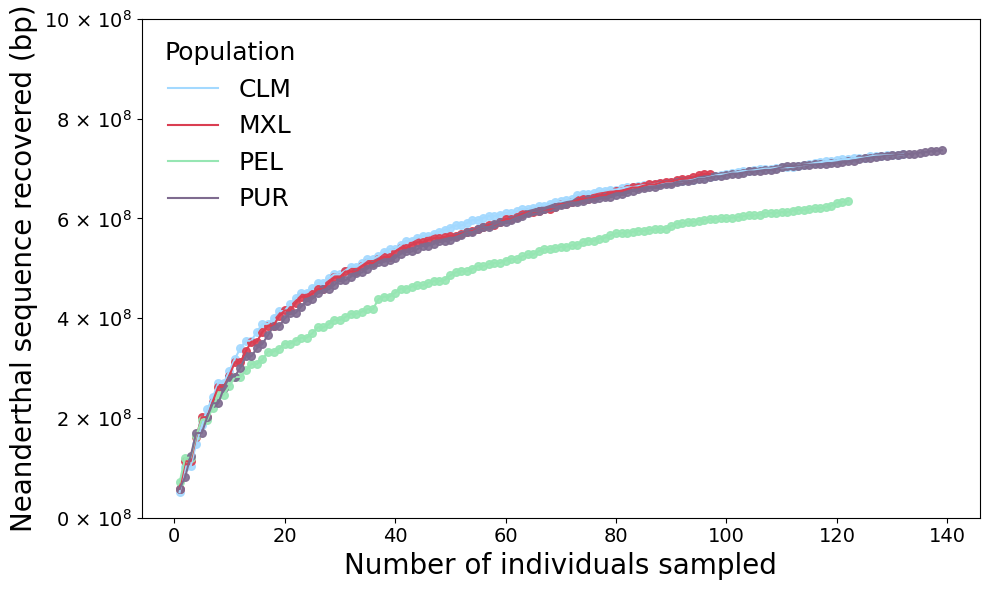

In [23]:
plot_recovered('neanderthal', scale_exp=8, ylim=10e8,
               out_name='AMR_nean_recovered_hmmix.png')

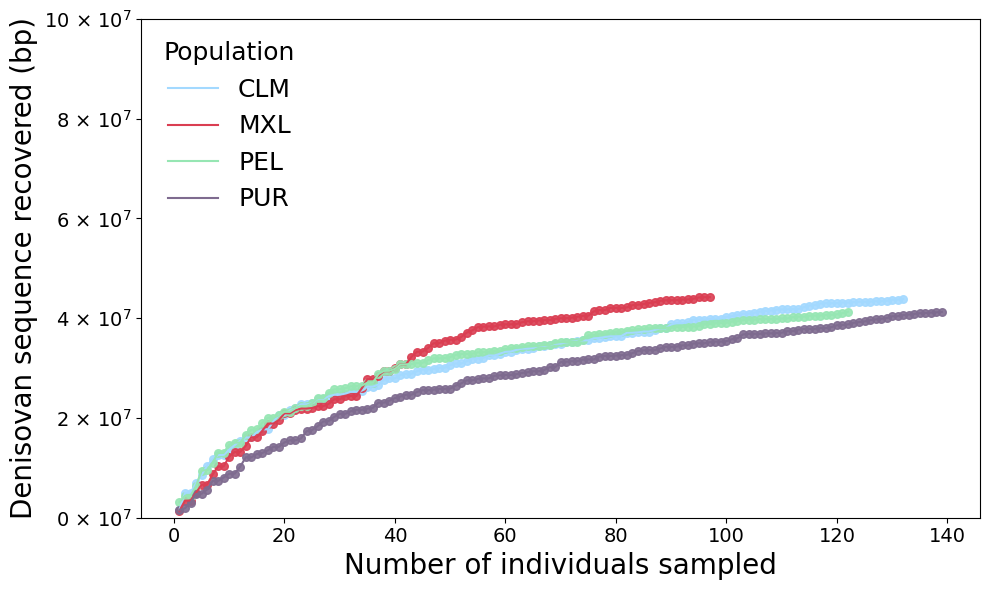

In [24]:
plot_recovered('denisovan', scale_exp=7, ylim=10e7,
               out_name='AMR_denisovan_recovered_hmmix.png',
               legend_loc='upper left')

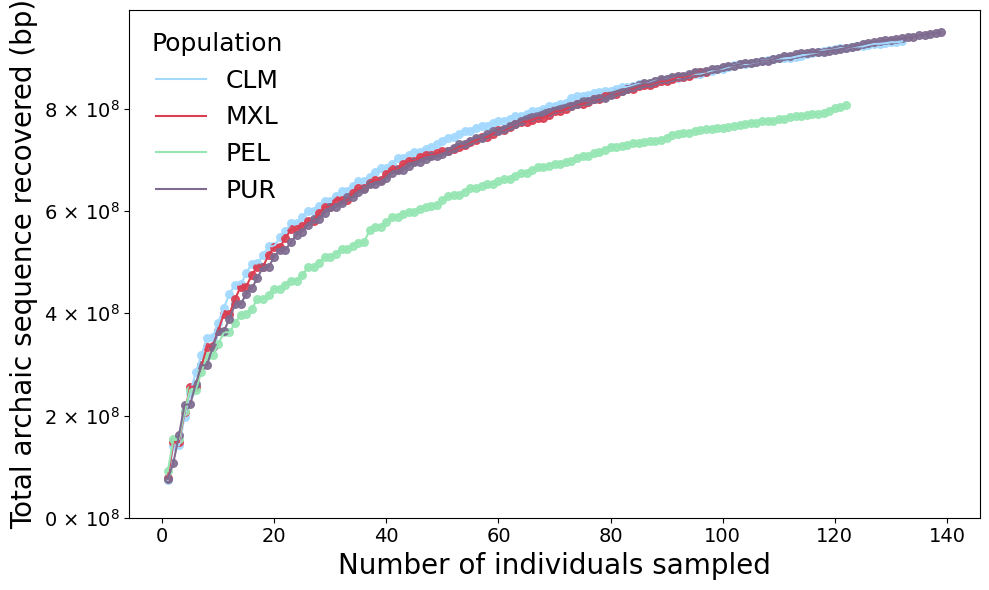

In [25]:
plot_recovered('all', scale_exp=8,
               out_name='AMR_all_archaic_recovered_hmmix.png',
               ylabel="Total archaic sequence recovered (bp)")

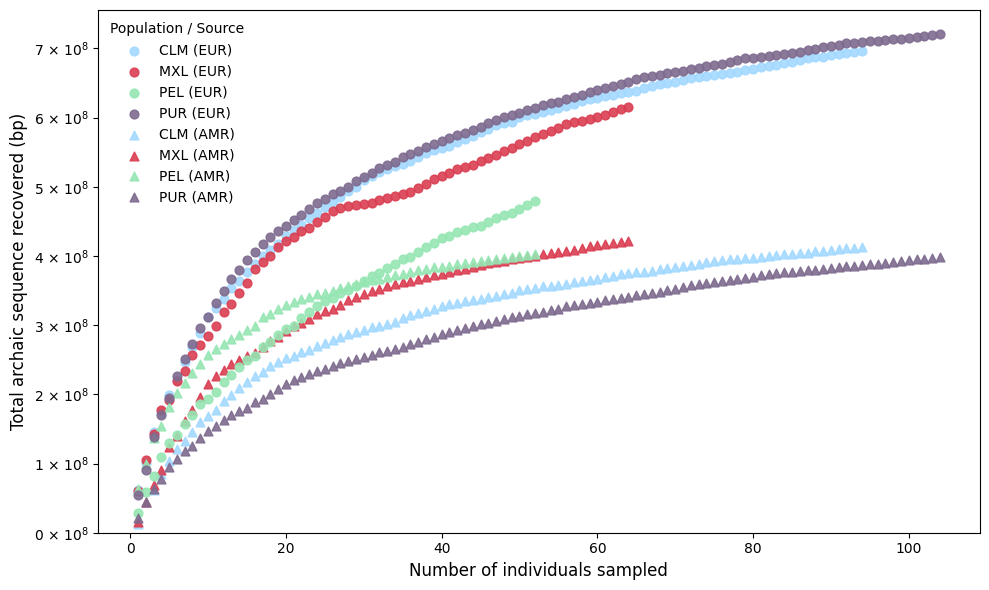

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

base_path = '/users/akuntzle/IBD_archaic_shared/data/recovered_archaic_by_admix_prop'
pops = ['CLM', 'MXL', 'PEL', 'PUR']
colors = {
    'CLM': '#A3D9FF',
    'MXL': '#DA3E52',
    'PEL': '#96E6B3',
    'PUR': '#7E6B8F'
}

plt.figure(figsize=(10, 6))

eur_handles = []
amr_handles = []

for pop in pops:
    # ---------- EUR ----------
    path_eur = f'{base_path}/{pop}_only_EUR_archaic_recovered.txt'
    with open(path_eur, 'r') as f:
        x = f.readline()[3:-1].split(', ')
        y = f.readline()[3:-1].split(', ')
    x = np.array([float(v) for v in x])
    y = np.array([float(v) for v in y])
    h_eur = plt.scatter(x, y,
                        color=colors[pop],
                        marker='o',
                        s=40,
                        alpha=0.9,
                        label=f'{pop} (EUR)')
    eur_handles.append(h_eur)

    # ---------- AMR ----------
    path_amr = f'{base_path}/{pop}_only_AMR_archaic_recovered.txt'
    with open(path_amr, 'r') as f:
        x = f.readline()[3:-1].split(', ')
        y = f.readline()[3:-1].split(', ')
    x = np.array([float(v) for v in x])
    y = np.array([float(v) for v in y])
    h_amr = plt.scatter(x, y,
                        color=colors[pop],
                        marker='^',
                        s=40,
                        alpha=0.9,
                        label=f'{pop} (AMR)')
    amr_handles.append(h_amr)

# ---------- formatting ----------
plt.xlabel("Number of individuals sampled", fontsize=12)
plt.ylabel("Total archaic sequence recovered (bp)", fontsize=12)

def sci_formatter(val, pos):
    scaled = val / 1e8
    if scaled.is_integer():
        return rf'{int(scaled)} × $10^{{8}}$'
    return rf'{scaled:.1f} × $10^{{8}}$'

plt.gca().yaxis.set_major_formatter(FuncFormatter(sci_formatter))
plt.ylim(bottom=0)

# EUR entries first, then all AMR entries
plt.legend(handles=eur_handles + amr_handles,
           title="Population / Source", frameon=False)

plt.tight_layout()
plt.savefig('/users/akuntzle/IBD_archaic_shared/figures/real_recovered_from_eur_amr')
plt.show()

# Here we handle all simulated analyses

In [27]:
def get_archaic_recovered_sims(df):

    if df is None or df.empty:
        return 0

    df = df.copy()
    df = df.rename(columns={"start": "Start", "end": "End"})
    df["Chromosome"] = "chr1"

    gr = pr.PyRanges(df[["Chromosome", "Start", "End"]])
    merged_df = gr.merge().df

    return (merged_df["End"] - merged_df["Start"]).sum()
        

In [28]:
def plot_archaic_recovered_sims(df):
    # df = pd.read_csv(
    #     f'/users/akuntzle/data/akuntzle/simulations_donor_eur/eur_donor/admix_csvs/{pop}_2tracts_rep{rep}_stitched.csv.gz'
    # )

    x = list(range(1, 101))
    y = []

    for i in x:
        hap_range = list(range(1, 1+i))
        subset = df[df['hap_id'].isin(hap_range)]
        y.append(get_archaic_recovered_sims(subset))

    return x, y

In [29]:
def get_ci_for_pop(pop, demo, admixing_pop):

    all_y = []

    for rep in range(1, 100 + 1):
        if rep % 50 == 0:
            print(rep)
        df = pd.read_csv(f'/users/akuntzle/data/akuntzle/simulations_donor_eur/{demo}/admix_csvs/{pop}_{admixing_pop}_arc_ancestry_rep{rep}.csv')
        x, y = plot_archaic_recovered_sims(df)
        all_y.append(y)

    all_y = np.array(all_y)

    mean_y = all_y.mean(axis=0)
    se = all_y.std(axis=0) / np.sqrt(all_y.shape[0])

    ci_lower = mean_y - 1.96 * se
    ci_upper = mean_y + 1.96 * se

    return x, mean_y, ci_lower, ci_upper

In [30]:
def plot_recovered_from_admixed2(demo, admixing_pop, linestyle='-', label_suffix=''):
    colors = {
        'CLM': '#A3D9FF',
        'MXL': '#DA3E52',
        'PEL': '#96E6B3',
        'PUR': '#7E6B8F'
    }
    pops = ["PUR", "PEL", "MXL", "CLM"]

    for pop in pops:
        print(pop)
        x, mean_y, ci_lower, ci_upper = get_ci_for_pop(pop, demo, admixing_pop)
        plt.plot(
            x, mean_y,
            color=colors[pop],
            linewidth=2,
            linestyle=linestyle,
            label=f'{pop}{label_suffix}'
        )
        plt.fill_between(
            x,
            ci_lower,
            ci_upper,
            color=colors[pop],
            alpha=0.2
        )

In [31]:
plt.figure(figsize=(8, 6))

plot_recovered_from_admixed2('no_bottleneck_donor', 'eur',
                            linestyle='-',  label_suffix=' (EUR)')
plot_recovered_from_admixed2('no_bottleneck_donor', 'amr',
                            linestyle='--', label_suffix=' (AMR)')

plt.xlabel("Number of Individuals")
plt.ylabel("Recovered Archaic Sequence (bp)")
plt.ylim(0, 2.1e7)
plt.legend()
plt.tight_layout()
plt.savefig("/users/akuntzle/IBD_archaic_shared/figures/simulated_recovered_amr_eur_yay.png")
plt.show()

PUR
50


KeyboardInterrupt: 

<Figure size 800x600 with 0 Axes>

# Shared archaic vs IBD

In [8]:
def get_pop_dict(df, pop_col, ind_col):
    population_dict = {}
    individual_dict = {}
    for _, row in df.iterrows():
        population = row[pop_col]
        individual = row[ind_col]
        if population not in population_dict:
            population_dict[population] = []
        population_dict[population].append(individual)
        individual_dict[individual] = population
    return population_dict, individual_dict
fam = pd.read_csv("/gpfs/data/sramacha/ukbiobank_jun17/phased_data/20130606_g1k_3202_samples_ped_population.txt", sep=' ')
pop_dict, ind_dict = get_pop_dict(fam, 'Population', 'SampleID')

In [11]:
ind_dict['HG01275']

'CLM'

In [6]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

def IBD_archaic_bivar(hmmix_diag, ibd_diag):
    # Define superpopulation mapping
    superpop_dict = {
        'MXL': 'AMR', 'PEL': 'AMR', 'PUR': 'AMR', 'CLM': 'AMR',
        'CHB': 'EAS', 'JPT': 'EAS', 'CHS': 'EAS', 'CDX': 'EAS', 'KHV': 'EAS',
        'CEU': 'EUR', 'TSI': 'EUR', 'GBR': 'EUR', 'FIN': 'EUR', 'IBS': 'EUR',
        'GIH': 'SAS', 'PJL': 'SAS', 'BEB': 'SAS', 'STU': 'SAS', 'ITU': 'SAS'
    }
    
    # Color and marker for each superpopulation
    style_map = {
        'AMR': {'color': 'orange',  'marker': 'o'},
        'EAS': {'color': 'green', 'marker': 's'},
        'EUR': {'color': 'blue',  'marker': '^'},
        'SAS': {'color': 'purple','marker': 'D'},
    }
    
    # Your subpopulations and data
    sub_pops = ['CHB', 'JPT', 'CHS', 'CDX', 'KHV', 
                'CEU', 'TSI', 'GBR', 'FIN', 'IBS', 
                'GIH', 'PJL', 'BEB', 'STU', 'ITU', 
                'MXL', 'PEL', 'PUR', 'CLM']
    
    # These are your data vectors
    # Make sure hmmix_diag and ibd_diag are in the same order as sub_pops
    # Example:
    # hmmix_diag = [ ... ]  # archaic sharing values
    # ibd_diag =   [ ... ]  # IBD values
    
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Plot each superpopulation separately with its unique color + marker
    for superpop, style in style_map.items():
        pops_in_group = [pop for pop in sub_pops if superpop_dict[pop] == superpop]
        indices = [sub_pops.index(pop) for pop in pops_in_group]
        x_vals = [hmmix_diag[i] for i in indices]
        y_vals = [ibd_diag[i] for i in indices]
    
        ax.scatter(x_vals, y_vals, color=style['color'], marker=style['marker'],
                   label=superpop,s=60)
    
        # Annotate each point
        for i in indices:
            ax.annotate(sub_pops[i],
                        (hmmix_diag[i], ibd_diag[i]),
                        textcoords="offset points", xytext=(3, 7),
                        ha='center', fontsize=10)
    
    # Axes and labels
    ax.set_xlabel('Average archaic sharing in base pairs')
    ax.set_ylabel('Average shared IBD in centimorgans')
    
    ax.set_xlim([min(hmmix_diag) - 1_000_000, max(hmmix_diag) + 1_000_000])
    ax.set_ylim([min(ibd_diag) - 10, max(ibd_diag) + 10])
    ax.tick_params(labelsize=10)
    
    # Custom legend
    legend_elements = [mlines.Line2D([0], [0],
                                      marker=style['marker'],
                                      color='w',
                                      markerfacecolor=style['color'],
                                      markersize=10,
                                      label=superpop)
                       for superpop, style in style_map.items()]
    ax.legend(handles=legend_elements, title="Superpopulations")
    
    plt.tight_layout()
    plt.show()



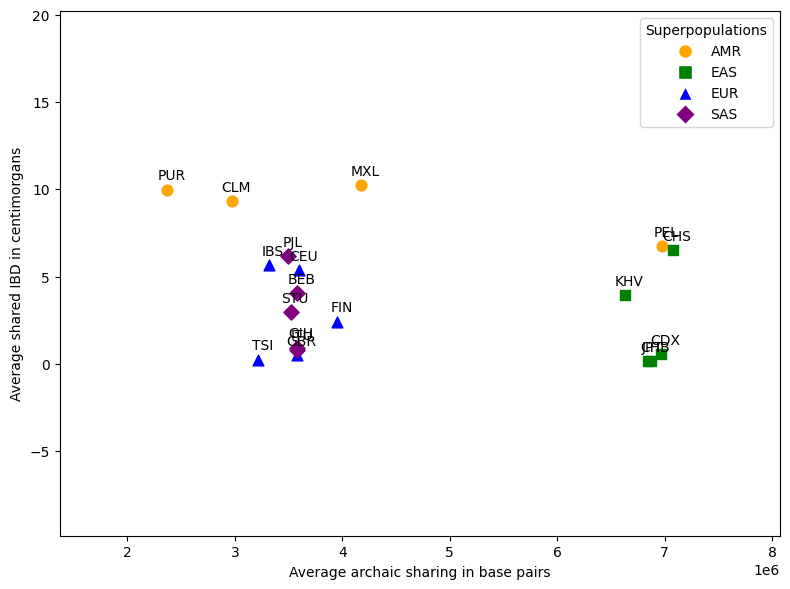

In [7]:


# ── 1. Initialize within-population pairs only ───────────────────────────────
combo_dict = {}
for key1, value1 in pop_dict.items():
    within_key = f'{key1}_{key1}'
    combo_dict[within_key] = {}
    for i in range(len(value1)):
        for j in range(i + 1, len(value1)):
            for hap1 in ['1', '2']:
                for hap2 in ['1', '2']:
                    id1 = value1[i] + '-' + hap1
                    id2 = value1[j] + '-' + hap2
                    combo_dict[within_key]['_'.join(sorted([id1, id2]))] = 0

# ── 2. Fill from IBD files ───────────────────────────────────────────────────
for i in range(1, 23):
    ibd = pd.read_csv(
        f'/gpfs/data/sramacha/datasets/1kgp_2023/ibdcalls/kgp_chr{i}_segments.ibd.gz',
        sep='\t', header=None, compression='gzip',
        names=['id1', 'hap1', 'id2', 'hap2', 'chr', 'start_bp', 'end_bp', 'CM']
    )
    for _, row in ibd.iterrows():
        pop1, pop2 = ind_dict[row['id1']], ind_dict[row['id2']]
        if pop1 != pop2:
            continue  # skip between-population
        ind_key = '_'.join(sorted([row['id1'] + '-' + str(row['hap1']),
                                   row['id2'] + '-' + str(row['hap2'])]))
        pop_key = f'{pop1}_{pop1}'
        if ind_key in combo_dict.get(pop_key, {}):
            combo_dict[pop_key][ind_key] += float(row['CM'])

# ── 3. Compute avg IBD per population ───────────────────────────────────────
avg_ibd_share = {key: statistics.mean(val.values()) 
                 for key, val in combo_dict.items() if val}

# ── 4. Build plot inputs ─────────────────────────────────────────────────────
sub_pops = ['CHB', 'JPT', 'CHS', 'CDX', 'KHV',
            'CEU', 'TSI', 'GBR', 'FIN', 'IBS',
            'GIH', 'PJL', 'BEB', 'STU', 'ITU',
            'MXL', 'PEL', 'PUR', 'CLM']

hmmix_diag = [statistics.mean(pd.read_csv(
    f'/users/akuntzle/data/akuntzle/hmmix_output/pairwise_comparisons_all/all_{pop}.txt',
    sep='\t', header=None, names=['id1', 'id2', 'total_shared'])['total_shared'])
    for pop in sub_pops]

ibd_diag = [avg_ibd_share[f'{pop}_{pop}'] for pop in sub_pops]

IBD_archaic_bivar(hmmix_diag, ibd_diag)

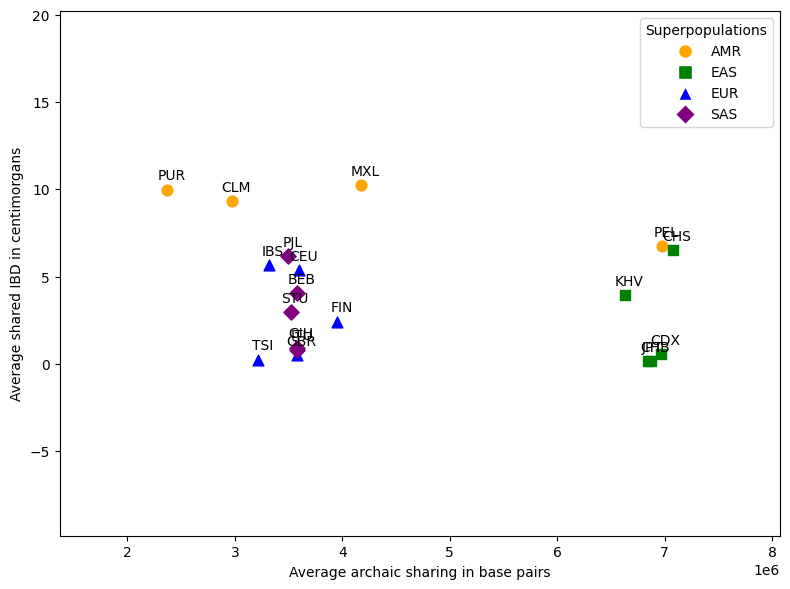

In [8]:
sub_pops = ['CHB', 'JPT', 'CHS', 'CDX', 'KHV', 
            'CEU', 'TSI', 'GBR', 'FIN', 'IBS', 
            'GIH', 'PJL', 'BEB', 'STU', 'ITU', 
            'MXL', 'PEL', 'PUR', 'CLM']

# Archaic sharing — raw bp (not divided by genome size)
hmmix_diag = []
for pop in sub_pops:
    comparisons = pd.read_csv(
        f'/users/akuntzle/data/akuntzle/hmmix_output/pairwise_comparisons_all/all_{pop}.txt',
        sep='\t', header=None, names=['id1', 'id2', 'total_shared']
    )
    hmmix_diag.append(statistics.mean(comparisons['total_shared']))

# IBD sharing
ibd_diag = [avg_ibd_share[f'{pop}_{pop}'] for pop in sub_pops]

IBD_archaic_bivar(hmmix_diag, ibd_diag)

# Admixture proportions versus IBD

In [ ]:
def get_pop_dict(df, pop_col, ind_col):
    population_dict = {}
    individual_dict = {}
    for _, row in df.iterrows():
        population = row[pop_col]
        individual = row[ind_col]
        if population not in population_dict:
            population_dict[population] = []
        population_dict[population].append(individual)
        individual_dict[individual] = population
    return population_dict, individual_dict
fam = pd.read_csv("/gpfs/data/sramacha/ukbiobank_jun17/phased_data/20130606_g1k_3202_samples_ped_population.txt", sep=' ')
pop_dict, ind_dict = get_pop_dict(fam, 'Population', 'SampleID')

In [50]:
# children_to_filter = pd.read_csv('/users/akuntzle/IBD_archaic_shared/data/children_to_remove.txt', header=None, names=['sampleID'])
children_to_filter = pd.read_csv(
    '/users/akuntzle/data/akuntzle/king_kinship/unrelatedunrelated_toberemoved.txt',
    sep=r'\s+',           # whitespace separator (KING uses spaces)
    header=None,
    names=['FID', 'sampleID']  # standard PLINK columns
)
ibd_df = []
for i in range(1, 23):
    ibd_chr = pd.read_csv(f'/users/akuntzle/data/akuntzle/1kgp_highcov_ibd_calls/kgp_chr{i}_segments.ibd.gz',sep='\t',header=None)
    ibd_chr.columns = ['ID1', 'hap1', 'ID2', 'hap2', 'chr', 'start_bp', 'end_bp', 'CM']
    children_set = set(children_to_filter['sampleID'])
    ibd_chr = ibd_chr[
        (~ibd_chr['ID1'].isin(children_set)) &
        (~ibd_chr['ID2'].isin(children_set))
    ].copy()
    ibd_df.append(ibd_chr)

all_ibd = pd.concat(ibd_df, ignore_index=True)

In [51]:
def get_props(pop_df, all_ibd, pop):
    pop_df['seg_len'] = pop_df['end'] - pop_df['start']

    ind_ancestry = (
        pop_df
        .groupby(['name', 'ancestry'])['seg_len']
        .sum()
    )
    wide = ind_ancestry.unstack(fill_value=0)
    prop = wide.div(wide.sum(axis=1), axis=0)
    wide_prop = wide.add_suffix('_bp').join(
        prop.add_suffix('_prop')
    )

    clm_set = set(pop_dict[pop])
    n_pop = len(clm_set)               # sub-population size

    clm_ibd = all_ibd[
        all_ibd['ID1'].isin(clm_set) &
        all_ibd['ID2'].isin(clm_set) &
        (all_ibd['ID1'] != all_ibd['ID2'])
    ]

    s1 = clm_ibd.groupby('ID1')['CM'].sum()
    s2 = clm_ibd.groupby('ID2')['CM'].sum()

    # total cM each individual shares with the rest of the population
    ibd_series = s1.add(s2, fill_value=0)

    # average over the (N - 1) potential within-population partners
    ibd_series = ibd_series / (n_pop - 1)
    ibd_series.name = 'avg_inpop_ibd'

    wide_prop = wide_prop.join(ibd_series)
    wide_prop['avg_inpop_ibd'] = wide_prop['avg_inpop_ibd'].fillna(0)
    return wide_prop

In [52]:
clm_df = pd.read_csv('/oscar/data/ehuertas/data/sharing/jaz/1kg_bed_files/CLM_lai.bed',sep='\t')
mxl_df = pd.read_csv('/oscar/data/ehuertas/data/sharing/jaz/1kg_bed_files/MXL_lai.bed',sep='\t')
pur_df = pd.read_csv('/oscar/data/ehuertas/data/sharing/jaz/1kg_bed_files/PUR_lai.bed',sep='\t')
pel_df = pd.read_csv('/oscar/data/ehuertas/data/sharing/jaz/1kg_bed_files/PEL_lai.bed',sep='\t')

In [53]:
clm_prop = get_props(clm_df, all_ibd,'CLM')
mxl_prop = get_props(mxl_df, all_ibd,'MXL')
pur_prop = get_props(pur_df, all_ibd,'PUR')
pel_prop = get_props(pel_df, all_ibd,'PEL')

In [54]:
def admix_prop_vs_ibd(admix_prop_pop, x_label):
    pop_data = {
        "Colombian":    clm_prop,
        "Mexican":      mxl_prop,
        "Peruvian":     pel_prop,
        "Puerto Rican": pur_prop,
    }
    colors = {
        "Colombian":    "#A3D9FF",
        "Mexican":      "#DA3E52",
        "Peruvian":     "#96E6B3",
        "Puerto Rican": "#7E6B8F",
    }
    fig, axes = plt.subplots(2, 2, figsize=(8, 6))
    axes = axes.flatten()
    for ax, (pop, df) in zip(axes, pop_data.items()):
        x = df[admix_prop_pop].values
        y = df["avg_inpop_ibd"].values
        print(f'before nan drop {len(x)}')
        # drop NaNs so linregress doesn't return NaN R²
        mask = ~(np.isnan(x) | np.isnan(y))
        x, y = x[mask], y[mask]
        ax.scatter(x, y, s=18, alpha=1.0, color=colors[pop])
        result = linregress(x, y)
        m, b   = result.slope, result.intercept
        r, p   = result.rvalue, result.pvalue
        r2     = r ** 2
        rho, p_spearman = spearmanr(x, y)
        x_line = np.linspace(x.min(), x.max(), 100)
        ax.plot(x_line, m * x_line + b, color=colors[pop], linewidth=2)
                # title: red + star if significant

        sig         = p_spearman < 0.05
        star        = " *" if sig else ""
        title_color = "red" if sig else "black"
        p_str       = f"{p_spearman:.2e}" if sig else f"{p_spearman:.2f}"
        ax.set_title(
            f"{pop}{star}\n$\\rho$ = {rho:.2f}, p = {p_str}",
            color=title_color,
        )
        print(f"{pop}   R² = {r2:.2f}   p = {p:.3e}   (n={len(x)} after NaN drop)")
        print(f"{pop}   Spearman ρ = {rho:.2f}   p = {p_spearman:.3e}")
        ax.set_xlim(0, 1)
        ax.set_ylim(-5, 50)
    fig.supxlabel(x_label)
    fig.supylabel(r"$\overline{\mathrm{IBD}}_i$  (cM)")
    plt.tight_layout()
    plt.savefig(f"/users/akuntzle/IBD_archaic_shared/figures/{admix_prop_pop}_admix_by_ibd.png")
    plt.show()

before nan drop 94
Colombian   R² = 0.36   p = 1.803e-10   (n=94 after NaN drop)
Colombian   Spearman ρ = 0.67   p = 2.643e-13
before nan drop 64
Mexican   R² = 0.04   p = 1.383e-01   (n=64 after NaN drop)
Mexican   Spearman ρ = -0.22   p = 7.822e-02
before nan drop 52
Peruvian   R² = 0.05   p = 9.877e-02   (n=52 after NaN drop)
Peruvian   Spearman ρ = -0.32   p = 2.100e-02
before nan drop 104
Puerto Rican   R² = 0.26   p = 2.874e-08   (n=104 after NaN drop)
Puerto Rican   Spearman ρ = 0.35   p = 3.069e-04


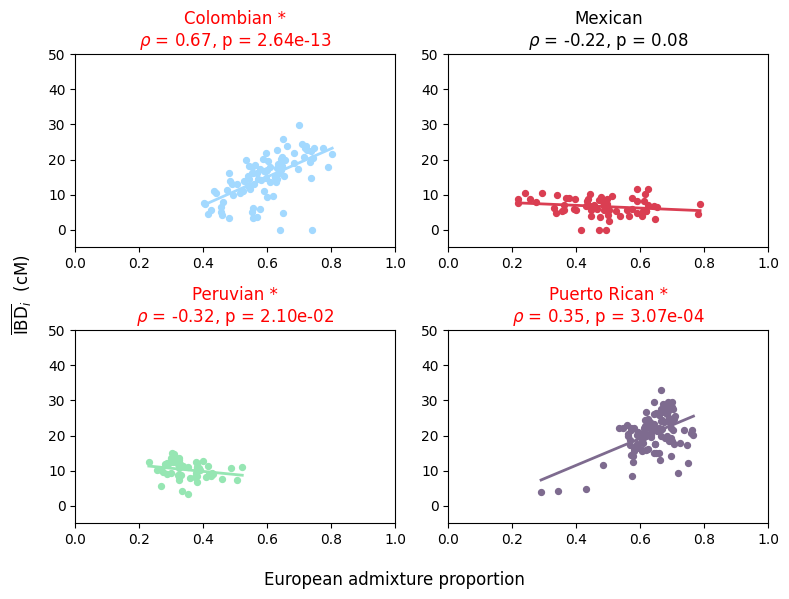

In [59]:
admix_prop_vs_ibd('EUR_prop', 'European admixture proportion')

before nan drop 94
Colombian   R² = 0.11   p = 1.141e-03   (n=94 after NaN drop)
Colombian   Spearman ρ = -0.35   p = 6.398e-04
before nan drop 64
Mexican   R² = 0.05   p = 7.714e-02   (n=64 after NaN drop)
Mexican   Spearman ρ = 0.26   p = 3.980e-02
before nan drop 52
Peruvian   R² = 0.31   p = 2.001e-05   (n=52 after NaN drop)
Peruvian   Spearman ρ = 0.49   p = 1.922e-04
before nan drop 104
Puerto Rican   R² = 0.26   p = 2.464e-08   (n=104 after NaN drop)
Puerto Rican   Spearman ρ = 0.41   p = 1.554e-05


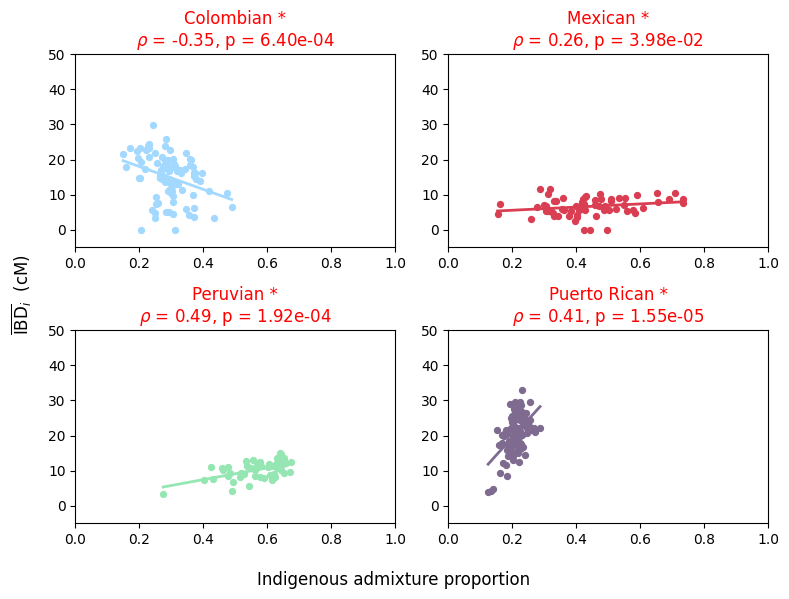

In [60]:
admix_prop_vs_ibd('AMR_prop', 'Indigenous admixture proportion')

before nan drop 94
Colombian   R² = 0.28   p = 3.694e-08   (n=94 after NaN drop)
Colombian   Spearman ρ = -0.62   p = 4.188e-11
before nan drop 64
Mexican   R² = 0.09   p = 1.538e-02   (n=64 after NaN drop)
Mexican   Spearman ρ = -0.29   p = 1.850e-02
before nan drop 52
Peruvian   R² = 0.25   p = 1.681e-04   (n=52 after NaN drop)
Peruvian   Spearman ρ = -0.41   p = 2.884e-03
before nan drop 104
Puerto Rican   R² = 0.44   p = 1.975e-14   (n=104 after NaN drop)
Puerto Rican   Spearman ρ = -0.53   p = 6.152e-09


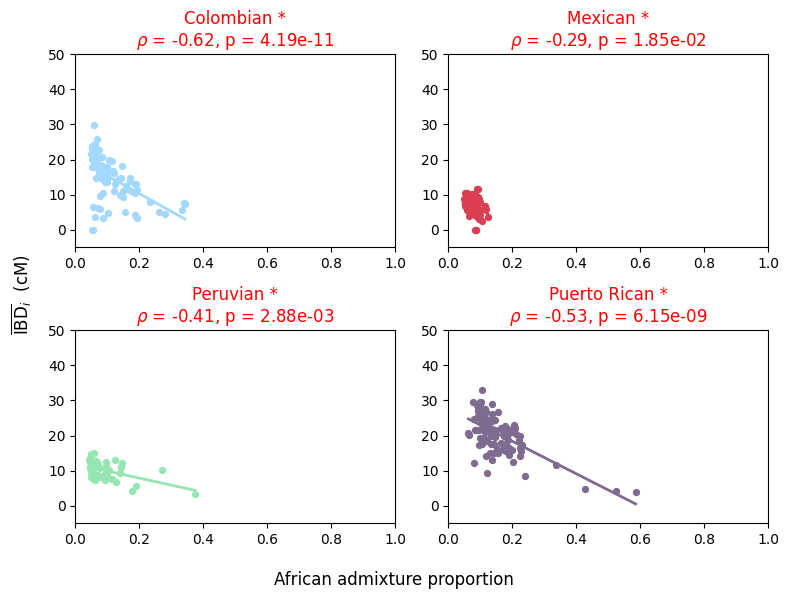

In [61]:
admix_prop_vs_ibd('AFR_prop', 'African admixture proportion')

In [62]:
def get_paired_ibd_pop(path, pop, no_trios=True):
    # children_to_filter = pd.read_csv('/users/akuntzle/IBD_archaic_shared/data/children_to_remove.txt', header=None, names=['sampleID'])
    children_to_filter = pd.read_csv(
    '/users/akuntzle/data/akuntzle/king_kinship/unrelatedunrelated_toberemoved.txt',
    sep=r'\s+',           # whitespace separator (KING uses spaces)
    header=None,
    names=['FID', 'sampleID']  # standard PLINK columns
)
    children_set = set(children_to_filter['sampleID'])
    big_probs = []
    ids = pop_dict[pop]
    pair_ibd_dict = {}

    for chrom in range(1, 23):
        ibd_chr = pd.read_csv(
        f"{path}kgp_chr{chrom}_segments.ibd.gz",
        sep='\t', header=None
        )
        ibd_chr.columns = ['ID1', 'hap1', 'ID2', 'hap2', 'chr', 'start_bp', 'end_bp', 'CM']

        if no_trios:
            ibd_chr = ibd_chr[
                (~ibd_chr['ID1'].isin(children_set)) &
                (~ibd_chr['ID2'].isin(children_set))
            ].copy()

        ibd_chr[['ID1', 'ID2']] = np.sort(ibd_chr[['ID1', 'ID2']], axis=1)

        ibd_chr = ibd_chr[ibd_chr['ID1'].isin(ids) & ibd_chr['ID2'].isin(ids)]

        grouped = ibd_chr.groupby(['ID1', 'ID2'])['CM'].sum()
        
        for key, val in grouped.items():
            if key not in pair_ibd_dict:
                pair_ibd_dict[key] = 0
            pair_ibd_dict[key] += val
    return pair_ibd_dict
            
        
        
        

In [63]:
MXL_pair_dict = get_paired_ibd_pop('/users/akuntzle/data/akuntzle/1kgp_highcov_ibd_calls/', 'MXL')
PUR_pair_dict = get_paired_ibd_pop('/users/akuntzle/data/akuntzle/1kgp_highcov_ibd_calls/', 'PUR')
PEL_pair_dict = get_paired_ibd_pop('/users/akuntzle/data/akuntzle/1kgp_highcov_ibd_calls/', 'PEL')
CLM_pair_dict = get_paired_ibd_pop('/users/akuntzle/data/akuntzle/1kgp_highcov_ibd_calls/', 'CLM')
IBS_pair_dict = get_paired_ibd_pop('/users/akuntzle/data/akuntzle/1kgp_highcov_ibd_calls/', 'IBS')

In [64]:
clm_values = list(CLM_pair_dict.values())
ibs_values = list(IBS_pair_dict.values())
pel_values = list(PEL_pair_dict.values())
pur_values = list(PUR_pair_dict.values())
mxl_values = list(MXL_pair_dict.values())

CLM vs IBS: U = 15804570.50, p-value = 2.669e-226
MXL vs IBS: U = 4691784.00, p-value = 8.888e-01
PEL vs IBS: U = 12588067.00, p-value = 1.443e-141
PUR vs IBS: U = 23635295.00, p-value = <1e-300


/tmp/ipykernel_935152/373960597.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


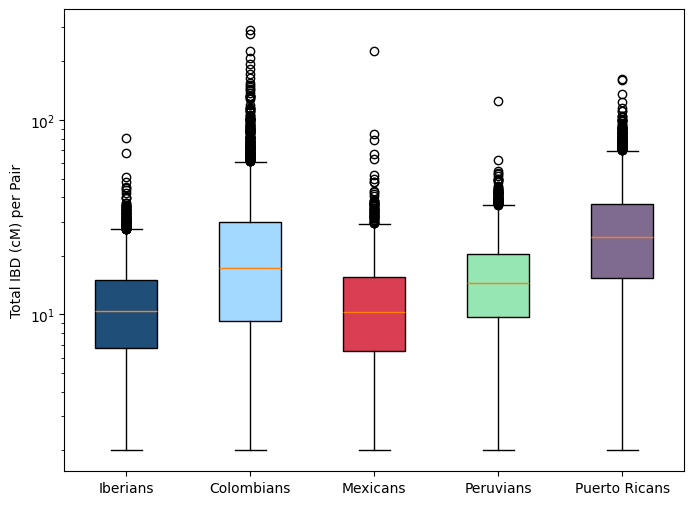

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# Your AMR populations
amr_pops = {
    "CLM": clm_values,
    "MXL": mxl_values,
    "PEL": pel_values,
    "PUR": pur_values
}

p_values = {}
u_stats = {}

for pop_name, pop_values in amr_pops.items():
    # Use 'exact' if sample sizes are small enough (<2000), otherwise default
    method = 'exact' if len(pop_values) < 2000 and len(ibs_values) < 2000 else 'asymptotic'
    stat, p = mannwhitneyu(pop_values, ibs_values, alternative='two-sided', method=method)
    
    # Handle underflow
    if p < 1e-300:
        p_str = "<1e-300"
    else:
        p_str = f"{p:.3e}"
        
    p_values[pop_name] = p_str
    u_stats[pop_name] = stat

# Print results
for pop in amr_pops.keys():
    print(f"{pop} vs IBS: U = {u_stats[pop]:.2f}, p-value = {p_values[pop]}")

# --- Optional: Boxplot with p-value annotations ---
fig, ax = plt.subplots(figsize=(8,6))

box = ax.boxplot(
    [ibs_values, clm_values, mxl_values, pel_values, pur_values],
    labels=["Iberians", "Colombians", "Mexicans", "Peruvians", "Puerto Ricans"],
    patch_artist=True
)

colors = ["#1f4e79", '#A3D9FF', '#DA3E52', '#96E6B3', '#7E6B8F']
for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)

ax.set_ylabel("Total IBD (cM) per Pair")
ax.set_yscale('log')
plt.savefig('/users/akuntzle/IBD_archaic_shared/figures/IBD_boxplots.png')

plt.show()

In [66]:
#returns the admixture proportion of an individual from a dataframe
def compute_admix_prop(df, ind, seq_length):
    summed_admix = df[df['hap_id'] == ind]['length'].sum()
    admix_prop = summed_admix/seq_length
    return(admix_prop)

In [67]:
def get_admix_prop_dict(df, seq_length, ts):
    ind_prop_dict = {}
    ind_list = [ind.id for ind in ts.individuals()]
    for ind in ind_list:
        ind_prop_dict[ind] = compute_admix_prop(df, ind, seq_length)
    return ind_prop_dict

In [68]:
def plot_admix_props(pop, demo, eur_pop_ID, mxb_pop_ID):
    all_mxb_props = []
    all_eur_props = []
    
    for i in range(1, 101):
        ts = tskit.load(f"/users/akuntzle/data/akuntzle/simulations_donor_eur/{demo}/tree_seqs/{pop}_rep{i}.ts.gz")
        eur_df = pd.read_csv(f'/users/akuntzle/data/akuntzle/simulations_donor_eur/{demo}/admix_csvs/{pop}_{eur_pop_ID}tracts_rep{i}_stitched.csv.gz')
        mxb_df = pd.read_csv(f'/users/akuntzle/data/akuntzle/simulations_donor_eur/{demo}/admix_csvs/{pop}_{mxb_pop_ID}tracts_rep{i}_stitched.csv.gz')

        eur_props_dict = get_admix_prop_dict(eur_df, ts.sequence_length, ts)
        mxb_props_dict = get_admix_prop_dict(mxb_df, ts.sequence_length, ts)
    
        all_eur_props += eur_props_dict.values()
        all_mxb_props += mxb_props_dict.values()
        
    plt.figure(figsize=(8,5))

    plt.hist(all_eur_props,
             bins=40,
             color="#3c6e71ff",
             alpha=0.7,
             label="European")
    
    plt.hist(all_mxb_props,
             bins=40,
             color="#dcc48eff",
             alpha=0.7,
             label="Indigenous American")

    plt.title(f"Distribution of admixture proportions for {pop} simulation, {demo}")
    plt.xlabel("Proportion")
    plt.ylabel("Count")
    plt.legend()
    
    plt.show()

In [69]:
def get_ibd_dict(ts):
    node_to_ind = {}
    for ind in ts.individuals():
        for n in ind.nodes:
            node_to_ind[n] = ind.id

    segments = ts.ibd_segments(min_span=1_000_000, store_segments=True)

    ibd_dict = {ind.id: 0 for ind in ts.individuals()}

    for pair, segment_list in segments.items():
        node1, node2 = pair
        ind1 = node_to_ind.get(node1)
        ind2 = node_to_ind.get(node2)

        for seg in segment_list:
            if ind1 is not None:
                ibd_dict[ind1] += seg.right - seg.left
            if ind2 is not None:
                ibd_dict[ind2] += seg.right - seg.left

    return ibd_dict

In [70]:
def plot_IBD_eur_corr(pop, demo, eur_pop_id):
    eur_props = []
    ibd_amnts = []
    for i in range(1, 101):
        ts = tskit.load(f"/users/akuntzle/data/akuntzle/simulations_donor_eur/{demo}/tree_seqs/{pop}_rep{i}.ts.gz")
        ibd_dict = get_ibd_dict(ts)
        eur_prop_df = pd.read_csv(f"/users/akuntzle/data/akuntzle/simulations_donor_eur/{demo}/admix_csvs/{pop}_{eur_pop_id}tracts_rep{i}_stitched.csv.gz")
        eur_prop_dict = get_admix_prop_dict(eur_prop_df, ts.sequence_length, ts)
        # print(eur_prop_df)
        for ind_id in eur_pur.keys():
            eur_props.append(eur_prop_dict[ind_id])
            ibd_amnts.append(ibd_dict[ind_id])
            
    # fit regression
    res = linregress(eur_props, ibd_amnts)
    slope = res.slope
    intercept = res.intercept
    r2 = res.rvalue**2
    pval = res.pvalue
    
    # regression line
    x_line = np.linspace(min(eur_props), max(eur_props), 200)
    y_line = slope * x_line + intercept
    
    plt.figure(figsize=(6,5))
    
    plt.scatter(
        eur_props, ibd_amnts,
        color="#7E6B8F",
        s=40,
        alpha=0.7,
    )
    
    plt.plot(x_line, y_line, linewidth=2)
    
    plt.xlabel("European admixture proportion")
    plt.ylabel("IBD shared with other individuals in the population")
    plt.title(f"European admixture prop versus IBD for {pop} {demo}")
    
    plt.text(
        0.05, 0.95,
        f"$R^2$ = {r2:.3f}\np = {pval:.3e}",
        transform=plt.gca().transAxes,
        verticalalignment="top"
    )
    
    plt.tight_layout()
    plt.show()

In [71]:
def get_IBD_eur_corr_CI(pop):
    import numpy as np
    import pandas as pd
    import tskit
    import statsmodels.api as sm

    eur_props_donor, ibd_amnts_donor = [], []
    eur_props_stand, ibd_amnts_stand = [], []

    for i in range(1, 101):
        # donor
        ts = tskit.load(f"/users/akuntzle/data/akuntzle/simulations_donor_eur/eur_donor/tree_seqs/{pop}_rep{i}.ts.gz")
        ibd_dict = get_ibd_dict(ts)
        eur_df = pd.read_csv(f"/users/akuntzle/data/akuntzle/simulations_donor_eur/eur_donor/admix_csvs/{pop}_10tracts_rep{i}_stitched.csv.gz")
        eur_prop_dict = get_admix_prop_dict(eur_df, ts.sequence_length, ts)

        for ind_id in eur_prop_dict:
            eur_props_donor.append(eur_prop_dict[ind_id])
            ibd_amnts_donor.append(ibd_dict[ind_id])

        # standard
        ts_no_don = tskit.load(f"/users/akuntzle/data/akuntzle/simulations_donor_eur/no_bottleneck_donor/tree_seqs/{pop}_rep{i}.ts.gz")
        ibd_dict_stand = get_ibd_dict(ts_no_don)
        eur_stand_df = pd.read_csv(f"/users/akuntzle/data/akuntzle/simulations_donor_eur/no_bottleneck_donor/admix_csvs/{pop}_7tracts_rep{i}_stitched.csv.gz")
        eur_prop_stand_dict = get_admix_prop_dict(eur_stand_df, ts_no_don.sequence_length, ts_no_don)

        for ind_id in eur_prop_stand_dict:
            eur_props_stand.append(eur_prop_stand_dict[ind_id])
            ibd_amnts_stand.append(ibd_dict_stand[ind_id])

    x_donor = np.array(eur_props_donor)
    y_donor = np.array(ibd_amnts_donor)
    x_stand = np.array(eur_props_stand)
    y_stand = np.array(ibd_amnts_stand)

    # donor model
    X_donor = sm.add_constant(x_donor)
    model_donor = sm.OLS(y_donor, X_donor).fit()
    x_pred_donor = np.linspace(x_donor.min(), x_donor.max(), 200)
    pred_donor = model_donor.get_prediction(sm.add_constant(x_pred_donor))
    y_pred_donor = pred_donor.predicted_mean
    ci_lower_donor, ci_upper_donor = pred_donor.conf_int().T

    # standard model
    X_stand = sm.add_constant(x_stand)
    model_stand = sm.OLS(y_stand, X_stand).fit()
    x_pred_stand = np.linspace(x_stand.min(), x_stand.max(), 200)
    pred_stand = model_stand.get_prediction(sm.add_constant(x_pred_stand))
    y_pred_stand = pred_stand.predicted_mean
    ci_lower_stand, ci_upper_stand = pred_stand.conf_int().T

    # interaction model
    x_all = np.concatenate([x_donor, x_stand])
    y_all = np.concatenate([y_donor, y_stand])
    pop_label = np.concatenate([np.zeros(len(x_donor)), np.ones(len(x_stand))])

    df = pd.DataFrame({"IBD": y_all, "Prop": x_all, "Pop": pop_label})
    df["Interaction"] = df["Prop"] * df["Pop"]

    X_interact = sm.add_constant(df[["Prop", "Pop", "Interaction"]])
    model_interact = sm.OLS(df["IBD"], X_interact).fit()

    return {
        "donor": (x_pred_donor, y_pred_donor, ci_lower_donor, ci_upper_donor, model_donor),
        "standard": (x_pred_stand, y_pred_stand, ci_lower_stand, ci_upper_stand, model_stand),
        "interaction_pval": model_interact.pvalues["Interaction"]
    }

In [72]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib.lines import Line2D

def plot_all_pops():
    pops = ["CLM", "MXL", "PEL", "PUR"]
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    axes = axes.flatten()

    donor_color = "#7E6B8F"      # purple
    standard_color = "#DCC48E"   # yellow

    for i, pop in enumerate(pops):
        ax = axes[i]
        res = get_IBD_eur_corr_CI(pop)

        xd, yd, ld, ud, model_d = res["donor"]
        xs, ys, ls, us, model_s = res["standard"]
        pval = res["interaction_pval"]

        # donor
        ax.plot(xd, yd, color=donor_color, linewidth=2)
        ax.fill_between(xd, ld, ud, color=donor_color, alpha=0.25)

        # standard
        ax.plot(xs, ys, color=standard_color, linewidth=2)
        ax.fill_between(xs, ls, us, color=standard_color, alpha=0.25)

        ax.set_title(pop)

        # same y limits
        ax.set_ylim(0, 1.5e7)

        # use ScalarFormatter for x10^7 style at top
        formatter = ScalarFormatter(useMathText=True)
        formatter.set_scientific(True)
        formatter.set_powerlimits((0, 0))  # forces scientific notation
        ax.yaxis.set_major_formatter(formatter)

        # remove individual labels (we’ll use shared)
        ax.set_xlabel("")
        ax.set_ylabel("")

        # print stats
        print(f"{pop}:")
        print(f"  Donor R² = {model_d.rsquared:.3f}, p = {model_d.pvalues[1]:.3e}")
        print(f"  Standard R² = {model_s.rsquared:.3f}, p = {model_s.pvalues[1]:.3e}")
        print(f"  Slope difference p-value = {pval:.3e}\n")

    # ONE shared axis labels
    fig.supxlabel("European admixture proportion", fontsize=12)
    fig.supylabel("Total IBD per pair", fontsize=12)

    # FIX legend: vertical on the right
    legend_handles = [
        Line2D([0], [0], color=donor_color, lw=2, label="Donor"),
        Line2D([0], [0], color=standard_color, lw=2, label="Standard")
    ]
    fig.legend(handles=legend_handles,
               loc="center left",   # right side
               bbox_to_anchor=(1.02, 0.5),  # slightly outside the figure
               ncol=1,               # vertical layout
               frameon=False)

    plt.tight_layout(rect=[0, 0, 0.95, 1])  # leave space on right for legend
    plt.savefig('/users/akuntzle/IBD_archaic_shared/figures/sims_IBD_admix_prop.png')
    plt.show()

CLM:
  Donor R² = 0.140, p = 0.000e+00
  Standard R² = 0.027, p = 9.328e-62
  Slope difference p-value = 1.154e-101

MXL:
  Donor R² = 0.097, p = 2.186e-224
  Standard R² = 0.004, p = 2.781e-09
  Slope difference p-value = 1.119e-95

PEL:
  Donor R² = 0.005, p = 1.425e-11
  Standard R² = 0.021, p = 2.912e-47
  Slope difference p-value = 2.083e-07

PUR:
  Donor R² = 0.091, p = 1.095e-208
  Standard R² = 0.032, p = 4.514e-72
  Slope difference p-value = 6.642e-41



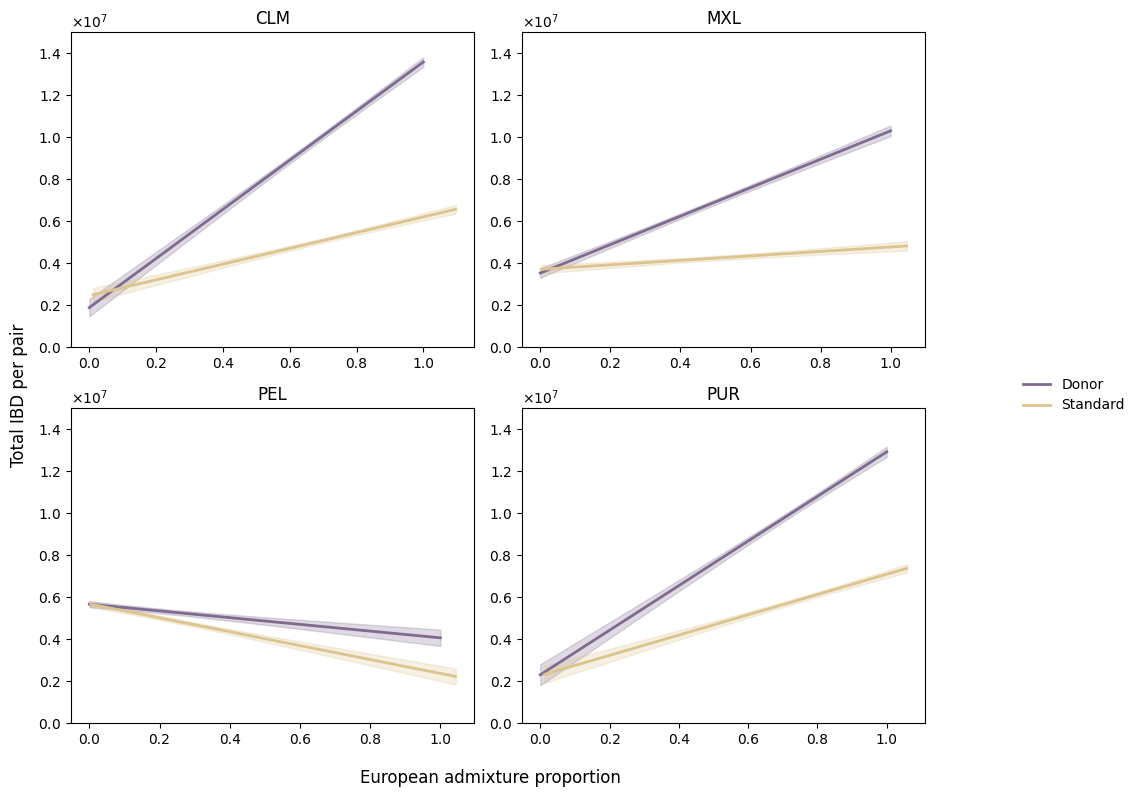

In [73]:
plot_all_pops()

In [74]:
def plot_IBD_eur_corr_CI_double_donor_recent(pop):
    # ---------- load data ----------
    eur_props_donor, ibd_amnts_donor = [], []
    eur_props_double, ibd_amnts_double = [], []
    eur_props_stand, ibd_amnts_stand = [], []
    eur_props_recent, ibd_amnts_recent = [], []
    eur_props_26gen, ibd_amnts_26gen = [], []
    eur_props_116gen, ibd_amnts_116gen = [], []
    eur_props_6don, ibd_amnts_6don = [], []

    for i in range(1, 101):
        # regular donor
        ts = tskit.load(f"/users/akuntzle/data/akuntzle/simulations_donor_eur/eur_donor/tree_seqs/{pop}_rep{i}.ts.gz")
        ibd_dict = get_ibd_dict(ts)
        eur_df = pd.read_csv(f"/users/akuntzle/data/akuntzle/simulations_donor_eur/eur_donor/admix_csvs/{pop}_10tracts_rep{i}_stitched.csv.gz")
        eur_prop_dict = get_admix_prop_dict(eur_df, ts.sequence_length, ts)
        for ind_id in eur_prop_dict:
            eur_props_donor.append(eur_prop_dict[ind_id])
            ibd_amnts_donor.append(ibd_dict[ind_id])

        # double donor
        ts_dd = tskit.load(f"/users/akuntzle/data/akuntzle/simulations_donor_eur/mxl_double_donor/tree_seqs/{pop}_rep{i}.ts.gz")
        ibd_dict_dd = get_ibd_dict(ts_dd)
        eur_dd_df = pd.read_csv(f"/users/akuntzle/data/akuntzle/simulations_donor_eur/mxl_double_donor/admix_csvs/{pop}_merged_89tracts_rep{i}.csv.gz")
        eur_dd_prop_dict = get_admix_prop_dict(eur_dd_df, ts_dd.sequence_length, ts_dd)
        for ind_id in eur_dd_prop_dict:
            eur_props_double.append(eur_dd_prop_dict[ind_id])
            ibd_amnts_double.append(ibd_dict_dd[ind_id])

        # standard (no donor)
        ts_std = tskit.load(f"/users/akuntzle/data/akuntzle/simulations_donor_eur/no_bottleneck_donor/tree_seqs/{pop}_rep{i}.ts.gz")
        ibd_dict_std = get_ibd_dict(ts_std)
        eur_std_df = pd.read_csv(f"/users/akuntzle/data/akuntzle/simulations_donor_eur/no_bottleneck_donor/admix_csvs/{pop}_7tracts_rep{i}_stitched.csv.gz")
        eur_std_prop_dict = get_admix_prop_dict(eur_std_df, ts_std.sequence_length, ts_std)
        for ind_id in eur_std_prop_dict:
            eur_props_stand.append(eur_std_prop_dict[ind_id])
            ibd_amnts_stand.append(ibd_dict_std[ind_id])

        # more recent double donor
        ts_rdd = tskit.load(f"/users/akuntzle/data/akuntzle/simulations_donor_eur/mxl_double_donor_recent/tree_seqs/{pop}_rep{i}.ts.gz")
        ibd_dict_rdd = get_ibd_dict(ts_rdd)
        eur_rdd_df = pd.read_csv(f"/users/akuntzle/data/akuntzle/simulations_donor_eur/mxl_double_donor_recent/admix_csvs/{pop}_merged_89tracts_rep{i}.csv.gz")
        eur_rdd_prop_dict = get_admix_prop_dict(eur_rdd_df, ts_rdd.sequence_length, ts_rdd)
        for ind_id in eur_rdd_prop_dict:
            eur_props_recent.append(eur_rdd_prop_dict[ind_id])
            ibd_amnts_recent.append(ibd_dict_rdd[ind_id])

        # no donor, 26 generations ago instead of 16
        ts_26gen = tskit.load(f"/users/akuntzle/data/akuntzle/simulations_donor_eur/mxl_26_admix/tree_seqs/{pop}_rep{i}.ts.gz")
        ibd_dict_26gen = get_ibd_dict(ts_26gen)
        eur_26gen_df = pd.read_csv(f"/users/akuntzle/data/akuntzle/simulations_donor_eur/mxl_26_admix/admix_csvs/{pop}_7tracts_rep{i}_stitched.csv.gz")
        eur_26gen_prop_dict = get_admix_prop_dict(eur_26gen_df, ts_26gen.sequence_length, ts_26gen)
        for ind_id in eur_26gen_prop_dict:
            eur_props_26gen.append(eur_26gen_prop_dict[ind_id])
            ibd_amnts_26gen.append(ibd_dict_26gen[ind_id])

        # no donor, 116 generations ago instead of 16
        ts_116gen = tskit.load(f"/users/akuntzle/data/akuntzle/simulations_donor_eur/mxl_26_admix/tree_seqs/{pop}_rep{i}.ts.gz")
        ibd_dict_116gen = get_ibd_dict(ts_116gen)
        eur_116gen_df = pd.read_csv(f"/users/akuntzle/data/akuntzle/simulations_donor_eur/mxl_26_admix/admix_csvs/{pop}_7tracts_rep{i}_stitched.csv.gz")
        eur_116gen_prop_dict = get_admix_prop_dict(eur_116gen_df, ts_116gen.sequence_length, ts_116gen)
        for ind_id in eur_116gen_prop_dict:
            eur_props_116gen.append(eur_116gen_prop_dict[ind_id])
            ibd_amnts_116gen.append(ibd_dict_116gen[ind_id])

        # 6 donors! totaling 10% admixture
        ts_6don = tskit.load(f"/users/akuntzle/data/akuntzle/simulations_donor_eur/mxl_donor6/tree_seqs/{pop}_rep{i}.ts.gz")
        ibd_dict_6don = get_ibd_dict(ts_6don) #MXL_totalIBSmerged_rep9.csv.gz
        eur_6don_df = pd.read_csv(f"/users/akuntzle/data/akuntzle/simulations_donor_eur/mxl_donor6/admix_csvs/{pop}_totalIBSmerged_rep{i}.csv.gz")
        eur_6don_prop_dict = get_admix_prop_dict(eur_6don_df, ts_6don.sequence_length, ts_6don)
        for ind_id in eur_6don_prop_dict:
            eur_props_6don.append(eur_6don_prop_dict[ind_id])
            ibd_amnts_6don.append(ibd_dict_6don[ind_id])

    # ---------- convert to arrays ----------
    x_donor = np.array(eur_props_donor)
    y_donor = np.array(ibd_amnts_donor)

    x_double = np.array(eur_props_double)
    y_double = np.array(ibd_amnts_double)

    x_stand = np.array(eur_props_stand)
    y_stand = np.array(ibd_amnts_stand)

    x_recent = np.array(eur_props_recent)
    y_recent = np.array(ibd_amnts_recent)

    x_26gen = np.array(eur_props_26gen)
    y_26gen = np.array(ibd_amnts_26gen)

    x_116gen = np.array(eur_props_116gen)
    y_116gen = np.array(ibd_amnts_116gen)

    x_6don = np.array(eur_props_6don)
    y_6don = np.array(ibd_amnts_6don)

    # ---------- fit donor ----------
    X_donor = sm.add_constant(x_donor)
    model_donor = sm.OLS(y_donor, X_donor).fit()
    x_pred_donor = np.linspace(x_donor.min(), x_donor.max(), 200)
    pred_donor = model_donor.get_prediction(sm.add_constant(x_pred_donor))
    y_pred_donor = pred_donor.predicted_mean
    ci_lower_donor, ci_upper_donor = pred_donor.conf_int().T

    # ---------- fit double donor ----------
    X_double = sm.add_constant(x_double)
    model_double = sm.OLS(y_double, X_double).fit()
    x_pred_double = np.linspace(x_double.min(), x_double.max(), 200)
    pred_double = model_double.get_prediction(sm.add_constant(x_pred_double))
    y_pred_double = pred_double.predicted_mean
    ci_lower_double, ci_upper_double = pred_double.conf_int().T

    # ---------- fit standard ----------
    X_stand = sm.add_constant(x_stand)
    model_stand = sm.OLS(y_stand, X_stand).fit()
    x_pred_stand = np.linspace(x_stand.min(), x_stand.max(), 200)
    pred_stand = model_stand.get_prediction(sm.add_constant(x_pred_stand))
    y_pred_stand = pred_stand.predicted_mean
    ci_lower_stand, ci_upper_stand = pred_stand.conf_int().T

    # ---------- fit recent double donor ----------
    X_recent = sm.add_constant(x_recent)
    model_recent = sm.OLS(y_recent, X_recent).fit()
    x_pred_recent = np.linspace(x_recent.min(), x_recent.max(), 200)
    pred_recent = model_recent.get_prediction(sm.add_constant(x_pred_recent))
    y_pred_recent = pred_recent.predicted_mean
    ci_lower_recent, ci_upper_recent = pred_recent.conf_int().T

    # ---------- fit 26 gen admixture ----------
    X_26gen = sm.add_constant(x_26gen)
    model_26gen = sm.OLS(y_26gen, X_26gen).fit()
    x_pred_26gen = np.linspace(x_26gen.min(), x_26gen.max(), 200)
    pred_26gen = model_26gen.get_prediction(sm.add_constant(x_pred_26gen))
    y_pred_26gen = pred_26gen.predicted_mean
    ci_lower_26gen, ci_upper_26gen = pred_26gen.conf_int().T

    # ---------- fit 116 gen admixture ----------
    X_116gen = sm.add_constant(x_116gen)
    model_116gen = sm.OLS(y_116gen, X_116gen).fit()
    x_pred_116gen = np.linspace(x_116gen.min(), x_116gen.max(), 200)
    pred_116gen = model_116gen.get_prediction(sm.add_constant(x_pred_116gen))
    y_pred_116gen = pred_116gen.predicted_mean
    ci_lower_116gen, ci_upper_116gen = pred_116gen.conf_int().T

    # ---------- fit 6 donors admixture ----------
    X_6don = sm.add_constant(x_6don)
    model_6don = sm.OLS(y_6don, X_6don).fit()
    x_pred_6don = np.linspace(x_6don.min(), x_6don.max(), 200)
    pred_6don = model_6don.get_prediction(sm.add_constant(x_pred_6don))
    y_pred_6don = pred_6don.predicted_mean
    ci_lower_6don, ci_upper_6don = pred_6don.conf_int().T

    # ---------- output ----------
    print("Donor R²:", model_donor.rsquared)
    print("Double donor R²:", model_double.rsquared)
    print("Standard R²:", model_stand.rsquared)
    print("Recent double donor R²:", model_recent.rsquared)
    print("26 generation admixture R²:", model_26gen.rsquared)
    print("166 generation admixture R²:", model_116gen.rsquared)
    print("6 donors admixture R²:", model_6don.rsquared)

    # ---------- plotting (progressive reveal) ----------
    from matplotlib.ticker import FuncFormatter

    def sci_formatter(val, pos):
        scaled = val / 1e6
        if scaled.is_integer():
            return rf'{int(scaled)} × $10^{{6}}$'
        return rf'{scaled:.1f} × $10^{{6}}$'

    # define the layers in reveal order
    layers = [
        dict(x=x_pred_stand,  y=y_pred_stand,  lo=ci_lower_stand,  hi=ci_upper_stand,
             color="#0072B2", ls="-",          label="Standard",
             tag="step1_standard"),
        dict(x=x_pred_donor,  y=y_pred_donor,  lo=ci_lower_donor,  hi=ci_upper_donor,
             color="#CC79A7", ls=":",          label="Single 10% European donor",
             tag="step2_plus_single"),
        dict(x=x_pred_recent, y=y_pred_recent, lo=ci_lower_recent, hi=ci_upper_recent,
             color="#009E73", ls="-.",         label="Two 10% European donors",
             tag="step3_plus_double"),
        dict(x=x_pred_6don,   y=y_pred_6don,   lo=ci_lower_6don,   hi=ci_upper_6don,
             color="#D55E00", ls=(0, (5, 1)),  label="Six 10% European donors",
             tag="step4_plus_six"),
    ]

    # fixed limits across all frames so the axes don't jump during the reveal
    all_x  = np.concatenate([L["x"]  for L in layers])
    all_lo = np.concatenate([L["lo"] for L in layers])
    all_hi = np.concatenate([L["hi"] for L in layers])
    xmin, xmax = all_x.min(), all_x.max()
    ymin, ymax = all_lo.min(), all_hi.max()
    ypad = 0.05 * (ymax - ymin)

    base = '/users/akuntzle/IBD_archaic_shared/figures/mxl_IBD_progressive'

    fig, ax = plt.subplots(figsize=(7, 5))
    for n in range(1, len(layers) + 1):
        ax.clear()
        for L in layers[:n]:
            ax.plot(L["x"], L["y"], color=L["color"], linewidth=2,
                    linestyle=L["ls"], label=L["label"])
            ax.fill_between(L["x"], L["lo"], L["hi"], color=L["color"], alpha=0.25)

        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin - ypad, ymax + ypad)
        ax.yaxis.set_major_formatter(FuncFormatter(sci_formatter))
        ax.set_xlabel("European admixture proportion", fontsize=14)
        ax.set_ylabel("IBD shared with other individuals", fontsize=14)
        ax.legend(loc="upper left")          # fixed location so it doesn't hop between frames
        fig.tight_layout()

        tag = layers[n - 1]["tag"]
        fig.savefig(f'{base}_{pop}_{tag}.png', dpi=200)

    plt.show()

Donor R²: 0.09722914916627867
Double donor R²: 0.238846558215555
Standard R²: 0.0035277718006738734
Recent double donor R²: 0.024250640417834424
26 generation admixture R²: 0.006355913144451386
166 generation admixture R²: 0.006355913144451386
6 donors admixture R²: 0.0030975855836670174


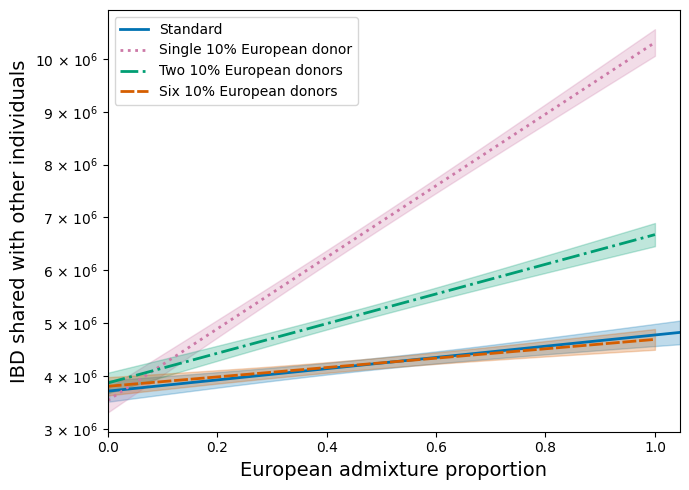

In [75]:
plot_IBD_eur_corr_CI_double_donor_recent('MXL')

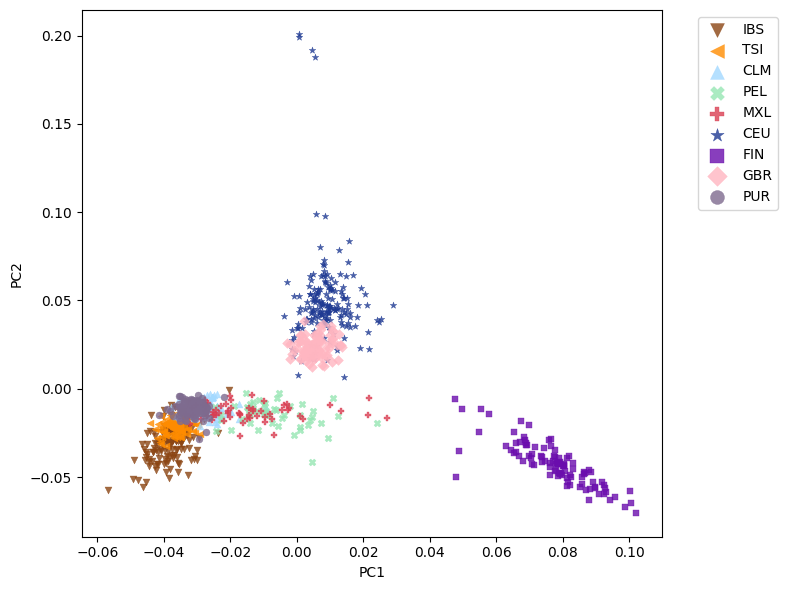

In [76]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle

# load IIDs
with open("/users/akuntzle/IBD_archaic_shared/code/smartpca_stuff/eur_admix_projected_merged_IDS_in_order.txt") as f:
    iids = [line.strip() for line in f]

# load eigenvectors
eig_path = "/users/akuntzle/IBD_archaic_shared/code/smartpca_stuff/eur_eig_vecs_eur_admix_projected_.txt"
try:
    eig = np.loadtxt(eig_path)
except ValueError:
    with open(eig_path, "r") as f:
        lines = f.readlines()
    cleaned = [line.replace('[', '').replace(']', '') for line in lines]
    eig = np.loadtxt(cleaned)

# get populations
pops = [ind_dict.get(iid, "UNKNOWN") for iid in iids]
unique_pops = sorted(set(pops))

# --- colors ---
color_map = {
    'CLM': '#A3D9FF',
    'MXL': '#DA3E52',
    'PEL': '#96E6B3',
    'PUR': '#7E6B8F',
    'TSI': '#FF8C00',   # orange
    'IBS': '#8B4513',   # brown
    'CEU': '#1F3A93',   # darker blue
    'GBR': '#FFB6C1',   # pink
    'FIN': '#6A0DAD',   # purple
}

# --- markers ---
# --- markers ---
marker_map = {
    'PUR': 'o',   # circle (was star)
    'CEU': '*',   # star  (was circle)
    'CLM': '^',
    'FIN': 's',
    'GBR': 'D',
    'IBS': 'v',
    'MXL': 'P',
    'PEL': 'X',
    'TSI': '<',
}

# bottom → top
plot_order = ['IBS', 'TSI', 'CLM', 'PEL', 'MXL', 'CEU', 'FIN', 'GBR', 'PUR']

plt.figure(figsize=(8, 6))
for pop in plot_order:
    if pop not in unique_pops:
        continue
    idx = [i for i, p in enumerate(pops) if p == pop]
    plt.scatter(eig[idx, 0], eig[idx, 1],
                label=pop,
                color=color_map.get(pop, 'gray'),
                marker=marker_map[pop],
                s=25,
                alpha=0.8,
                linewidths=0.3)

plt.xlabel("PC1")
plt.ylabel("PC2")
# plt.title("PCA: PC1 vs PC2 (EUR)")
plt.legend(markerscale=2, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('/users/akuntzle/IBD_archaic_shared/figures/european_pca.png')
plt.show()


CLM — fraction of pairs with zero IBD on shared ancestry:
  EUR: 35.5%  (n_pairs = 17,484)
  AMR: 47.3%  (n_pairs = 17,484)
  AFR: 56.3%  (n_pairs = 17,484)

MXL — fraction of pairs with zero IBD on shared ancestry:
  EUR: 58.4%  (n_pairs = 8,064)
  AMR: 64.7%  (n_pairs = 8,064)
  AFR: 86.2%  (n_pairs = 8,064)

PEL — fraction of pairs with zero IBD on shared ancestry:
  EUR: 57.4%  (n_pairs = 5,304)
  AMR: 41.7%  (n_pairs = 5,304)
  AFR: 84.6%  (n_pairs = 5,304)

PUR — fraction of pairs with zero IBD on shared ancestry:
  EUR: 20.5%  (n_pairs = 21,424)
  AMR: 30.2%  (n_pairs = 21,424)
  AFR: 36.4%  (n_pairs = 21,424)


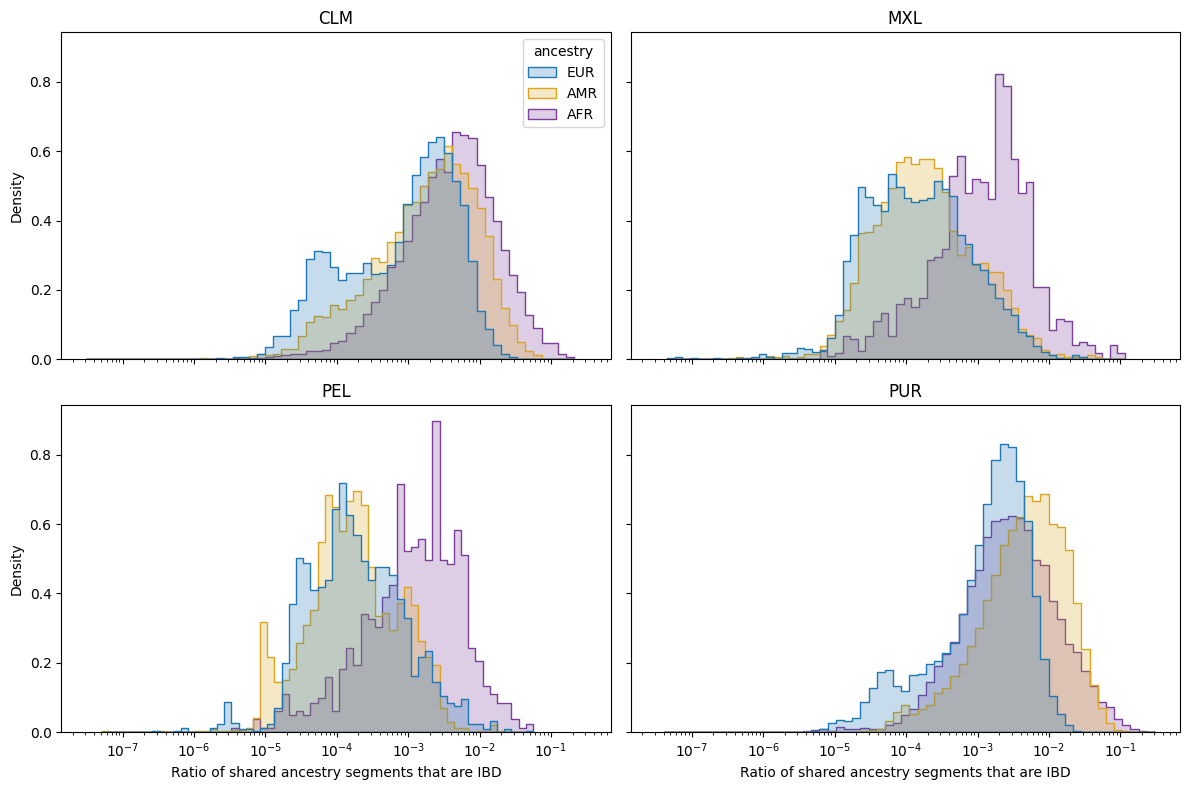

In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = "/users/akuntzle/data/akuntzle/IBD_ancestry_tracts"
POPS = ["CLM", "MXL", "PEL", "PUR"]
ANCESTRIES = ["EUR", "AMR", "AFR"]
palette = {"EUR": "#1f77b4", "AMR": "#daa520", "AFR": "#7b3f99"}

# ---- load everything ----
data = {}
for pop in POPS:
    frames = []
    for anc in ANCESTRIES:
        df = pd.read_csv(f"{DATA_DIR}/{pop}_{anc}_IBD_ratios.csv")
        df["ancestry"] = anc
        frames.append(df[["ancestry", "ratio"]])
    data[pop] = pd.concat(frames, ignore_index=True)

# ---- report zero-IBD fractions ----
for pop in POPS:
    print(f"\n{pop} — fraction of pairs with zero IBD on shared ancestry:")
    for anc in ANCESTRIES:
        sub = data[pop][data[pop]["ancestry"] == anc]
        pct_zero = (sub["ratio"] == 0).mean() * 100
        print(f"  {anc}: {pct_zero:.1f}%  (n_pairs = {len(sub):,})")

# ---- 2x2 panel of histograms (non-zero only) ----
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
for ax, pop in zip(axes.flat, POPS):
    nz = data[pop][data[pop]["ratio"] > 0]
    sns.histplot(
        data=nz,
        x="ratio",
        hue="ancestry",
        hue_order=ANCESTRIES,
        palette=palette,
        bins=60,
        log_scale=(True, False),
        element="step",
        stat="density",
        common_norm=False,
        ax=ax,
        legend=(ax is axes.flat[0]),   # one legend, top-left panel
    )
    ax.set_title(pop)
    ax.set_xlabel("Ratio of shared ancestry segments that are IBD")
    ax.set_ylabel("Density")

# fig.suptitle("Non-zero IBD coverage by ancestry, per population", y=1.02)
fig.tight_layout()
plt.savefig(f"{DATA_DIR}/AMR_ancestry_IBD_ratio_hist_nonzero.png", dpi=200, bbox_inches="tight")
plt.show()

## IBD from sims

In [ ]:
def ibd_pairs(pop, rep):
    ts = tskit.load(f"/users/akuntzle/data/akuntzle/simulations_donor_eur/no_bottleneck_donor/tree_seqs/{pop}_rep{rep}.ts.gz")
    node_to_ind = {}
    for ind in ts.individuals():
        for n in ind.nodes:
            node_to_ind[n] = ind.id

    segments = ts.ibd_segments(min_span=1_000_000, store_segments=True)

    # initialize every N-choose-2 pair to 0 so absent pairs still show up
    ind_ids = sorted(ind.id for ind in ts.individuals())
    ibd_dict = {pair: 0 for pair in combinations(ind_ids, 2)}

    for (node1, node2), segment_list in segments.items():
        ind1 = node_to_ind.get(node1)
        ind2 = node_to_ind.get(node2)
        if ind1 is None or ind2 is None or ind1 == ind2:
            continue
        key = (ind1, ind2) if ind1 < ind2 else (ind2, ind1)
        for seg in segment_list:
            ibd_dict[key] += seg.right - seg.left

    return list(ibd_dict.values())

In [ ]:
clm_dist = []
for i in range(1,101):
    clm_dist += ibd_pairs('CLM',i)

In [ ]:
mxl_dist = []
for i in range(1,101):
    mxl_dist += ibd_pairs('MXL',i)

In [ ]:
pur_dist = []
for i in range(1,101):
    pur_dist += ibd_pairs('PUR',i)

In [ ]:
pel_dist = []
for i in range(1,101):
    pel_dist += ibd_pairs('PEL',i)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# Your AMR populations
amr_pops = {
    "CLM": clm_values,
    "MXL": mxl_values,
    "PEL": pel_values,
    "PUR": pur_values
}

p_values = {}
u_stats = {}

for pop_name, pop_values in amr_pops.items():
    # Use 'exact' if sample sizes are small enough (<2000), otherwise default
    method = 'exact' if len(pop_values) < 2000 and len(ibs_values) < 2000 else 'asymptotic'
    stat, p = mannwhitneyu(pop_values, ibs_values, alternative='two-sided', method=method)
    
    # Handle underflow
    if p < 1e-300:
        p_str = "<1e-300"
    else:
        p_str = f"{p:.3e}"
        
    p_values[pop_name] = p_str
    u_stats[pop_name] = stat

# Print results
for pop in amr_pops.keys():
    print(f"{pop} vs IBS: U = {u_stats[pop]:.2f}, p-value = {p_values[pop]}")

# --- Optional: Boxplot with p-value annotations ---
fig, ax = plt.subplots(figsize=(8,6))

box = ax.boxplot(
    [ibs_values, clm_values, mxl_values, pel_values, pur_values],
    labels=["Iberians", "Colombians", "Mexicans", "Peruvians", "Puerto Ricans"],
    patch_artist=True
)

colors = ["#1f4e79", '#A3D9FF', '#DA3E52', '#96E6B3', '#7E6B8F']
for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)

ax.set_ylabel("Total IBD (cM) per Pair")
ax.set_yscale('log')
plt.savefig('/users/akuntzle/IBD_archaic_shared/figures/IBD_boxplots.png')

plt.show()

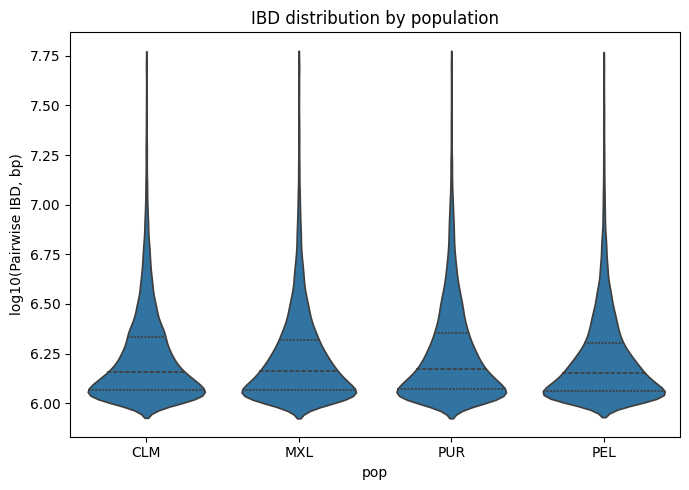

In [16]:
df = pd.DataFrame({
    "pop": (["CLM"]*len(clm_dist) + ["MXL"]*len(mxl_dist)
            + ["PUR"]*len(pur_dist) + ["PEL"]*len(pel_dist)),
    "ibd": list(clm_dist) + list(mxl_dist) + list(pur_dist) + list(pel_dist),
})
df = df[df["ibd"] > 0]
df["log_ibd"] = np.log10(df["ibd"])

fig, ax = plt.subplots(figsize=(7, 5))
sns.violinplot(data=df, x="pop", y="log_ibd", inner="quartile", ax=ax)
ax.set_ylabel("log10(Pairwise IBD, bp)")
ax.set_title("IBD distribution by population")
plt.tight_layout()
plt.show()

# Haplogroup analyses

In [78]:
y_haps = pd.read_csv('/users/akuntzle/IBD_archaic_shared/data/mito_and_Y_haplo_1kgp/3.haplogroups.txt',header=None,sep='\s+')

In [79]:
y_haps = y_haps.rename(columns={
    y_haps.columns[0]: 'SampleID',
    y_haps.columns[1]: 'pop',
    y_haps.columns[2]: 'most_derived_SNP',
    y_haps.columns[3]: 'short_haplo',
    y_haps.columns[4]: 'pipe',
    y_haps.columns[5]: 'long_haplo',
})

In [80]:
y_indo_eur = ['R1b', 'I1', 'N1', 'J2', 'R1a', 'I2','G2', 'J1']

In [83]:
y_pel = y_haps[(y_haps['pop'] == 'PEL')]
y_pur = y_haps[y_haps['pop'] == 'PUR']
y_clm = y_haps[y_haps['pop'] == 'CLM']
y_mxl = y_haps[y_haps['pop'] == 'MXL']

In [84]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import entropy, chi2_contingency
from itertools import combinations

rng = np.random.default_rng(42)
N_BOOT = 5000

def shannon(h):
    if len(h) == 0: return np.nan
    _, c = np.unique(h, return_counts=True); return entropy(c)
def effective_n(h):
    return np.exp(shannon(h))
def simpson_evenness(h):
    if len(h) == 0: return np.nan
    _, c = np.unique(h, return_counts=True); p = c / c.sum(); return 1 - (p**2).sum()
METRICS = {'shannon_H': shannon, 'effective_n': effective_n, 'simpson_evenness': simpson_evenness}

# ---- CHUNK 1: bootstrap 95% CIs + plot ----
def bootstrap_diversity(groups, title='', savepath=None):
    boot = {m: {} for m in METRICS}
    for pop, h in groups.items():
        idx = rng.integers(0, len(h), size=(N_BOOT, len(h)))
        samp = h[idx]
        for m, fn in METRICS.items():
            boot[m][pop] = np.array([fn(r) for r in samp])
    rows = []
    for pop, h in groups.items():
        row = {'pop': pop, 'n': len(h)}
        for m, fn in METRICS.items():
            b = boot[m][pop]
            row[m], row[f'{m}_lo'], row[f'{m}_hi'] = fn(h), np.percentile(b, 2.5), np.percentile(b, 97.5)
        rows.append(row)
    summary = pd.DataFrame(rows).set_index('pop')
    print(summary.round(3))

    pops = list(groups)
    fig, axes = plt.subplots(1, len(METRICS), figsize=(13, 4))
    for ax, m in zip(axes, METRICS):
        pt = np.array([METRICS[m](groups[p]) for p in pops])
        lo = np.array([np.percentile(boot[m][p], 2.5) for p in pops])
        hi = np.array([np.percentile(boot[m][p], 97.5) for p in pops])
        ax.errorbar(pops, pt,
            yerr=[np.maximum(pt - lo, 0), np.maximum(hi - pt, 0)],
            fmt='o', capsize=5, color='black')
        ax.set_title(m); ax.set_xlabel('Population')
    fig.suptitle(title); plt.tight_layout()
    if savepath: plt.savefig(savepath, dpi=300, bbox_inches='tight')
    plt.show()
    return summary, boot

# ---- CHUNK 2: significance ----
def _perm_p(a, b, fn, n_perm):
    o = fn(a) - fn(b); pl = np.concatenate([a, b]); na = len(a)
    d = np.array([(lambda x: fn(x[:na]) - fn(x[na:]))(rng.permutation(pl)) for _ in range(n_perm)])
    return o, (np.sum(np.abs(d) >= abs(o)) + 1) / (n_perm + 1)

def significance(groups, n_perm=10000):
    pops = list(groups)
    # omnibus 1: does composition differ across ANY pops?
    all_h = sorted(set().union(*map(set, groups.values())))
    table = np.array([[np.sum(groups[p] == hh) for p in pops] for hh in all_h])
    chi2, p_chi, dof, _ = chi2_contingency(table)
    print(f"omnibus chi-square (composition): p={p_chi:.4g}")
    # omnibus 2: does each diversity metric differ across ANY pops?
    sizes = [len(groups[p]) for p in pops]; cuts = np.cumsum(sizes)[:-1]
    pooled = np.concatenate([groups[p] for p in pops])
    for m, fn in METRICS.items():
        spread = lambda gs: np.nanvar([fn(g) for g in gs])
        obs = spread([groups[p] for p in pops])
        null = np.array([spread(np.split(rng.permutation(pooled), cuts)) for _ in range(n_perm)])
        print(f"omnibus permutation ({m}): p={(np.sum(null >= obs) + 1) / (n_perm + 1):.4f}")
    # pairwise (which pops differ), Shannon H, Bonferroni
    pairs = list(combinations(pops, 2))
    print("\npairwise (shannon_H):")
    for a, b in pairs:
        o, p = _perm_p(groups[a], groups[b], shannon, n_perm)
        print(f"  {a} vs {b}: Δ={o:+.3f}, p={p:.4f}, p_adj={min(p*len(pairs),1):.4f}")

     n_haplogroups  shannon_H  effective_n  simpson_evenness  max_prop
PEL              5   1.169993     3.221970          0.586667  0.600000
PUR              5   0.890031     2.435205          0.419753  0.750000
CLM              3   0.626766     1.871549          0.362123  0.774194
MXL              3   0.578325     1.783050          0.304498  0.823529


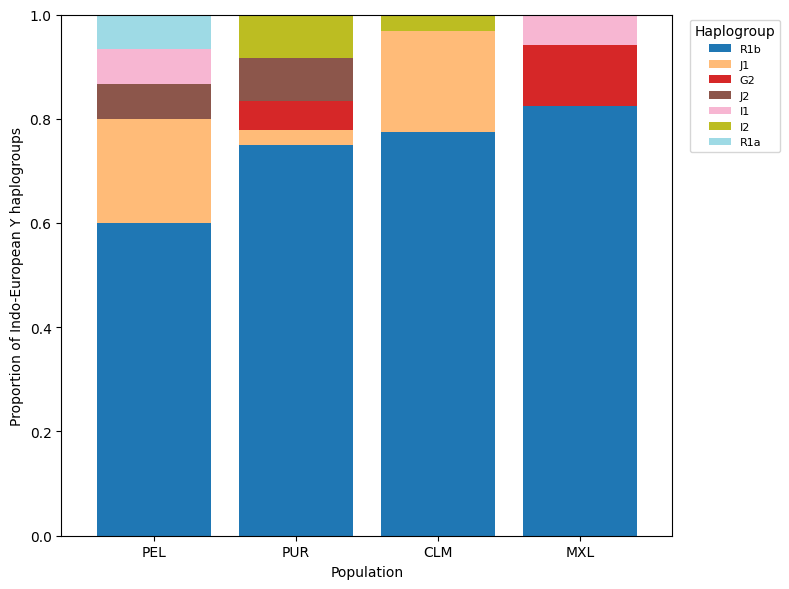

In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import entropy

amr_pops = {'PEL': y_pel, 'PUR': y_pur, 'CLM': y_clm, 'MXL': y_mxl}

# proportions of European-origin haplogroups in each pop (out of European-Y males)
props = {}
for pop, df in amr_pops.items():
    sub = df.loc[df['short_haplo'].isin(y_indo_eur), 'short_haplo']
    props[pop] = sub.value_counts(normalize=True)

prop_df = pd.DataFrame(props).fillna(0)         # rows = haplogroups, cols = pops
prop_df = prop_df.loc[prop_df.sum(axis=1).sort_values(ascending=False).index]  # most common haps on top

# diversity stats per pop
diversity = pd.DataFrame({
    'n_haplogroups':    (prop_df > 0).sum(axis=0),
    'shannon_H':        prop_df.apply(lambda c: entropy(c[c > 0])),
    'effective_n':      prop_df.apply(lambda c: np.exp(entropy(c[c > 0]))),
    'simpson_evenness': prop_df.apply(lambda c: 1 - (c**2).sum()),
    'max_prop':         prop_df.max(axis=0),
})
print(diversity)
# calming muted palette
calm = ['#6b8ead', '#a3c3a8', '#d9b8a3', '#c08497', '#8e9aaf',
        '#cb9b7a', '#9bb1b5', '#bfa6c9', '#a8b89a', '#d4a59a',
        '#7fa6a1', '#c7b2a0', '#b0c4b1', '#dcc48e', '#8a9b9d', '#caa6a0']
n = prop_df.shape[0]
colors = (calm * (n // len(calm) + 1))[:n]   # cycle if more haplogroups than colors
# stacked bar
fig, ax = plt.subplots(figsize=(8, 6))
prop_df.T.plot(kind='bar', stacked=True, ax=ax, colormap='tab20', width=0.8)
ax.set_ylabel('Proportion of Indo-European Y haplogroups')
ax.set_xlabel('Population')
# ax.set_title('European Y haplogroup composition by AMR population')
ax.legend(title='Haplogroup', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax.set_ylim(0, 1)

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('/users/akuntzle/IBD_archaic_shared/figures/Y_haplos')
plt.show()

      n  shannon_H  shannon_H_lo  shannon_H_hi  effective_n  effective_n_lo  \
pop                                                                           
PEL  15      1.170         0.485         1.437        3.222           1.624   
PUR  36      0.890         0.426         1.163        2.435           1.531   
CLM  31      0.627         0.318         0.842        1.872           1.374   
MXL  17      0.578         0.000         0.874        1.783           1.000   

     effective_n_hi  simpson_evenness  simpson_evenness_lo  \
pop                                                          
PEL           4.207             0.587                0.240   
PUR           3.199             0.420                0.205   
CLM           2.321             0.362                0.175   
MXL           2.396             0.304                0.000   

     simpson_evenness_hi  
pop                       
PEL                0.729  
PUR                0.585  
CLM                0.508  
MXL              

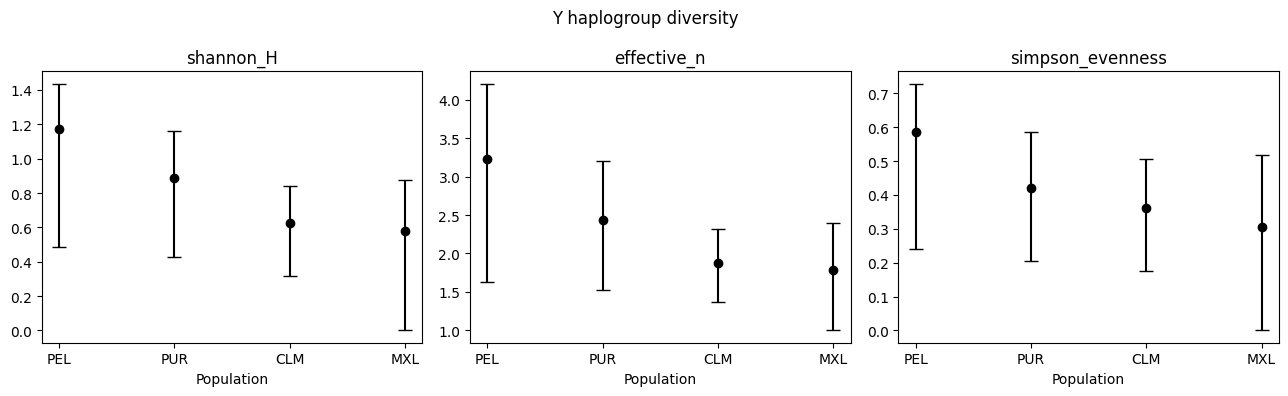

omnibus chi-square (composition): p=0.0424
omnibus permutation (shannon_H): p=0.3735
omnibus permutation (effective_n): p=0.3411
omnibus permutation (simpson_evenness): p=0.4383

pairwise (shannon_H):
  PEL vs PUR: Δ=+0.280, p=0.4700, p_adj=1.0000
  PEL vs CLM: Δ=+0.543, p=0.1199, p_adj=0.7193
  PEL vs MXL: Δ=+0.592, p=0.1853, p_adj=1.0000
  PUR vs CLM: Δ=+0.263, p=0.3554, p_adj=1.0000
  PUR vs MXL: Δ=+0.312, p=0.3947, p_adj=1.0000
  CLM vs MXL: Δ=+0.048, p=0.9303, p_adj=1.0000


In [86]:
y_groups = {pop: df.loc[df['short_haplo'].isin(y_indo_eur), 'short_haplo'].to_numpy()
            for pop, df in amr_pops.items()}
bootstrap_diversity(y_groups, title='Y haplogroup diversity',
                    savepath='/users/akuntzle/IBD_archaic_shared/figures/Y_diversity_CI')
significance(y_groups)

     n_haplogroups  shannon_H  effective_n  simpson_evenness  max_prop
PEL             11   2.303488    10.009038          0.888889  0.200000
PUR             20   2.503255    12.222207          0.845679  0.361111
CLM             17   2.603077    13.505227          0.903226  0.225806
MXL             13   2.425480    11.307652          0.892734  0.235294


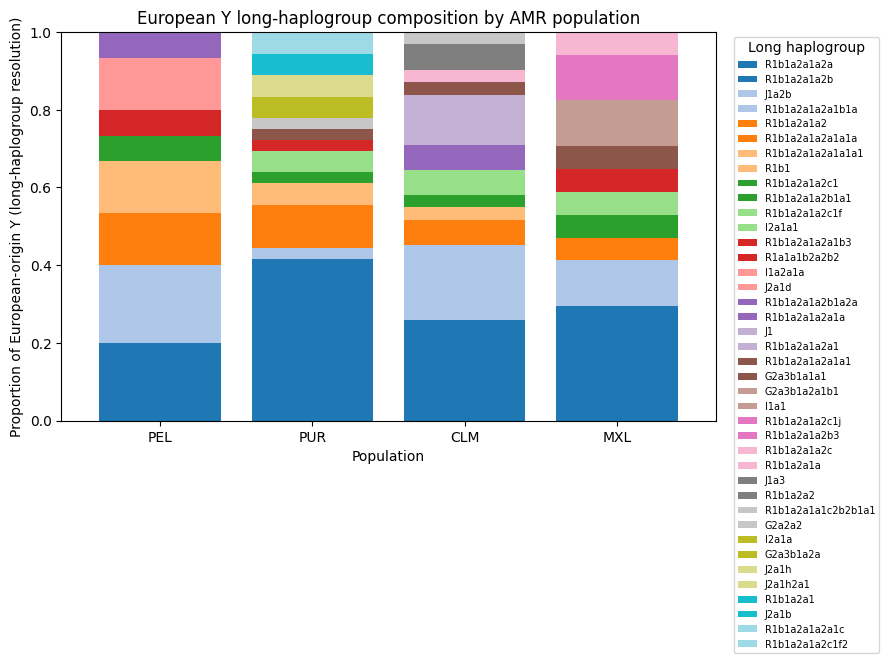

In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import entropy

amr_pops = {'PEL': y_pel, 'PUR': y_pur, 'CLM': y_clm, 'MXL': y_mxl}

# keep only rows whose SHORT haplogroup is European, then count by LONG haplogroup
props = {}
for pop, df in amr_pops.items():
    sub = df.loc[df['short_haplo'].isin(y_indo_eur), 'long_haplo']
    props[pop] = sub.value_counts(normalize=True)

prop_df = pd.DataFrame(props).fillna(0)
prop_df = prop_df.loc[prop_df.sum(axis=1).sort_values(ascending=False).index]

# diversity stats per pop (now at long-haplogroup resolution)
diversity = pd.DataFrame({
    'n_haplogroups':    (prop_df > 0).sum(axis=0),
    'shannon_H':        prop_df.apply(lambda c: entropy(c[c > 0])),
    'effective_n':      prop_df.apply(lambda c: np.exp(entropy(c[c > 0]))),
    'simpson_evenness': prop_df.apply(lambda c: 1 - (c**2).sum()),
    'max_prop':         prop_df.max(axis=0),
})
print(diversity)

# stacked bar — long-haplogroup composition
fig, ax = plt.subplots(figsize=(9, 6))
prop_df.T.plot(kind='bar', stacked=True, ax=ax, colormap='tab20', width=0.8)
ax.set_ylabel('Proportion of European-origin Y (long-haplogroup resolution)')
ax.set_xlabel('Population')
ax.set_title('European Y long-haplogroup composition by AMR population')
ax.legend(title='Long haplogroup', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('help.png')
plt.show()

      n  shannon_H  shannon_H_lo  shannon_H_hi  effective_n  effective_n_lo  \
pop                                                                           
PEL  15      2.303         1.529         2.211       10.009           4.615   
PUR  36      2.503         1.769         2.558       12.222           5.867   
CLM  31      2.603         1.989         2.576       13.505           7.307   
MXL  17      2.425         1.610         2.313       11.308           5.003   

     effective_n_hi  simpson_evenness  simpson_evenness_lo  \
pop                                                          
PEL           9.125             0.889                0.738   
PUR          12.905             0.846                0.699   
CLM          13.147             0.903                0.807   
MXL          10.106             0.893                0.734   

     simpson_evenness_hi  
pop                       
PEL                0.880  
PUR                0.900  
CLM                0.914  
MXL              

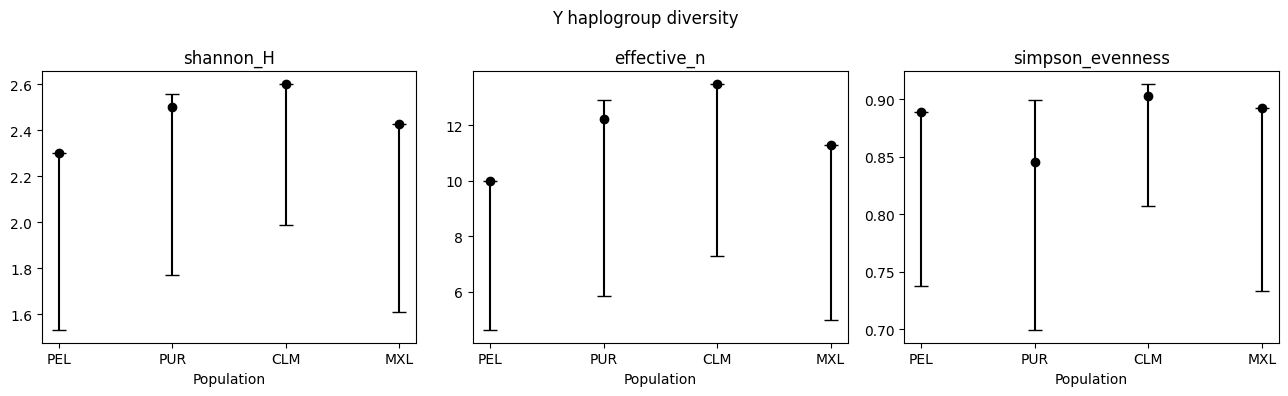

omnibus chi-square (composition): p=0.1236
omnibus permutation (shannon_H): p=0.9516
omnibus permutation (effective_n): p=0.9612
omnibus permutation (simpson_evenness): p=0.6876

pairwise (shannon_H):
  PEL vs PUR: Δ=-0.200, p=0.7868, p_adj=1.0000
  PEL vs CLM: Δ=-0.300, p=0.6460, p_adj=1.0000
  PEL vs MXL: Δ=-0.122, p=0.6784, p_adj=1.0000
  PUR vs CLM: Δ=-0.100, p=0.7669, p_adj=1.0000
  PUR vs MXL: Δ=+0.078, p=0.9161, p_adj=1.0000
  CLM vs MXL: Δ=+0.178, p=0.7340, p_adj=1.0000


In [98]:
y_groups = {}
for pop, df in amr_pops.items():
    y_groups[pop] = df.loc[df['short_haplo'].isin(y_indo_eur), 'long_haplo'].to_numpy()
bootstrap_diversity(y_groups, title='Y haplogroup diversity',
                    savepath='/users/akuntzle/IBD_archaic_shared/figures/Y_diversity_CI')
significance(y_groups)

## Mitochondrial

In [89]:
mito_haps = pd.read_csv('/users/akuntzle/IBD_archaic_shared/data/mito_and_Y_haplo_1kgp/1kGP_3202_haplogroup_results.txt',sep='\t')
mito_haps[mito_haps['SampleID'].isin(pop_dict['PUR'])]['Haplogroup'].unique()

array(['A2z', 'A2', 'L1b1a3', 'A2k1', 'B2b3a', 'C1b2', 'C',
       "L3d1'2'3'4'5'6", 'L1b1a7a', 'A2am', 'L0a1b1a', 'K1a4a1h',
       'J2a1a1a', 'U5b2b3a', 'L3e2b', 'C1c+195', 'C1b4', 'L3e1e2',
       'J1c2e', 'L1c3b1a', 'A2k', 'U2e1a1', 'J1b1a1', 'L0a1a2', 'H1b',
       'U4b1b1', 'A2ah', 'H13a', 'L2b1a', 'L3b1a+@16124', 'L2c', 'L1b2a',
       'L3d4', 'C1d', 'L2a1l1b', 'T2a1a'], dtype=object)

In [90]:
eur_pops = ['CEU', 'GBR', 'FIN', 'TSI', 'IBS']
eur_samples = [s for pop in eur_pops for s in pop_dict[pop]]

mito_eur = mito_haps[mito_haps['SampleID'].isin(eur_samples)]

In [91]:
indo_eur_mito = ['H', 'I', 'J','K','T','V','W','X','U']
mito_pel = mito_haps[mito_haps['SampleID'].isin(pop_dict['PEL'])]
mito_pur = mito_haps[mito_haps['SampleID'].isin(pop_dict['PUR'])]
mito_mxl = mito_haps[mito_haps['SampleID'].isin(pop_dict['MXL'])]
mito_clm = mito_haps[mito_haps['SampleID'].isin(pop_dict['CLM'])]

In [92]:
amr_mito = {'PEL': mito_pel, 'PUR': mito_pur, 'CLM': mito_clm, 'MXL': mito_mxl}

In [93]:
eur_macros = {}
for pop, df in amr_mito.items():
    macros = df['Haplogroup'].astype(str).str[0]              # first letter only
    eur_macros[pop] = macros[macros.isin(indo_eur_mito)].to_numpy()

   PEL    PUR  CLM    MXL
H  1.0  0.105  0.4  0.538
T  0.0  0.053  0.6  0.000
J  0.0  0.474  0.0  0.000
U  0.0  0.316  0.0  0.154
V  0.0  0.000  0.0  0.154
W  0.0  0.000  0.0  0.154
K  0.0  0.053  0.0  0.000


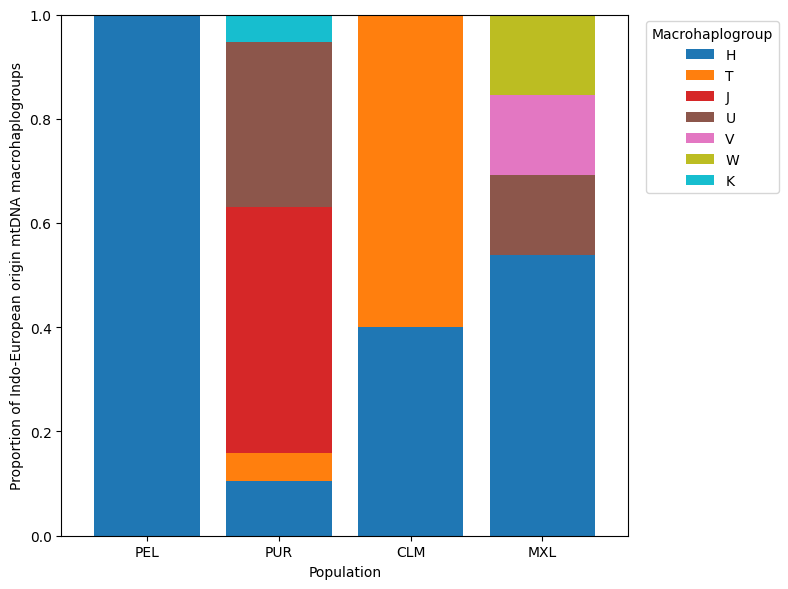

In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import entropy

indo_eur_mito = ['H', 'I', 'J', 'K', 'T', 'V', 'W', 'X', 'U']
amr_mito = {'PEL': mito_pel, 'PUR': mito_pur, 'CLM': mito_clm, 'MXL': mito_mxl}

# ---- extract macro-letter and filter to European mtDNA haplogroups ----
eur_macros = {}
for pop, df in amr_mito.items():
    macros = df['Haplogroup'].astype(str).str[0]              # first letter only
    eur_macros[pop] = macros[macros.isin(indo_eur_mito)].to_numpy()

# ---- proportions per pop ----
props = {pop: pd.Series(macros).value_counts(normalize=True)
         for pop, macros in eur_macros.items()}
prop_df = pd.DataFrame(props).fillna(0)
prop_df = prop_df.loc[prop_df.sum(axis=1).sort_values(ascending=False).index]
print(prop_df.round(3))

# ---- stacked bar (macro composition among European mtDNA) ----
fig, ax = plt.subplots(figsize=(8, 6))
prop_df.T.plot(kind='bar', stacked=True, ax=ax, colormap='tab10', width=0.8)
ax.set_ylabel('Proportion of Indo-European origin mtDNA macrohaplogroups')
ax.set_xlabel('Population')
# ax.set_title('European mtDNA macrohaplogroup composition by AMR population')
ax.legend(title='Macrohaplogroup', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('/users/akuntzle/IBD_archaic_shared/figures/mtDNA_haplos.png')
plt.show()

      n  shannon_H  shannon_H_lo  shannon_H_hi  effective_n  effective_n_lo  \
pop                                                                           
PEL   2      0.000         0.000         0.000        1.000           1.000   
PUR  19      1.265         0.766         1.457        3.543           2.151   
CLM   5      0.673         0.000         0.673        1.960           1.000   
MXL  13      1.197         0.540         1.352        3.311           1.716   

     effective_n_hi  simpson_evenness  simpson_evenness_lo  \
pop                                                          
PEL           1.000             0.000                0.000   
PUR           4.293             0.659                0.465   
CLM           1.960             0.480                0.000   
MXL           3.864             0.639                0.355   

     simpson_evenness_hi  
pop                       
PEL                0.000  
PUR                0.742  
CLM                0.480  
MXL              

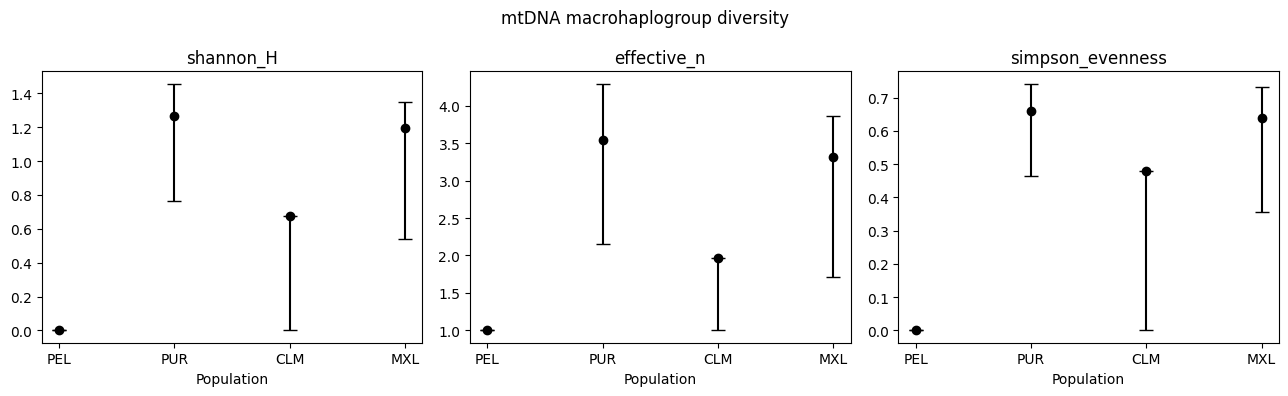

omnibus chi-square (composition): p=0.000892
omnibus permutation (shannon_H): p=0.2211
omnibus permutation (effective_n): p=0.8697
omnibus permutation (simpson_evenness): p=0.2025

pairwise (shannon_H):
  PEL vs PUR: Δ=-1.265, p=0.2692, p_adj=1.0000
  PEL vs CLM: Δ=-0.673, p=0.2892, p_adj=1.0000
  PEL vs MXL: Δ=-1.197, p=0.3437, p_adj=1.0000
  PUR vs CLM: Δ=+0.592, p=0.1400, p_adj=0.8399
  PUR vs MXL: Δ=+0.068, p=0.8558, p_adj=1.0000
  CLM vs MXL: Δ=-0.524, p=0.2075, p_adj=1.0000


In [96]:
bootstrap_diversity(eur_macros, title='mtDNA macrohaplogroup diversity',
                    savepath='/users/akuntzle/IBD_archaic_shared/figures/mtDNA_diversity_CI')
significance(eur_macros)

         PEL    PUR  CLM    MXL
H13a1a1  1.0  0.000  0.0  0.000
T2b4c    0.0  0.000  0.6  0.000
H6a1a7   0.0  0.000  0.4  0.000
J1b1a1   0.0  0.316  0.0  0.000
U5b2b3a  0.0  0.158  0.0  0.000
H10e     0.0  0.000  0.0  0.154
W+194    0.0  0.000  0.0  0.154
V25      0.0  0.000  0.0  0.154
H1ba     0.0  0.000  0.0  0.154
J2a1a1a  0.0  0.105  0.0  0.000
U4b1b1   0.0  0.105  0.0  0.000
H2a5     0.0  0.000  0.0  0.077
H2a      0.0  0.000  0.0  0.077
U5b1f1a  0.0  0.000  0.0  0.077
U6d3a    0.0  0.000  0.0  0.077
H94      0.0  0.000  0.0  0.077
H1b      0.0  0.053  0.0  0.000
H13a     0.0  0.053  0.0  0.000
T2a1a    0.0  0.053  0.0  0.000
K1a4a1h  0.0  0.053  0.0  0.000
J1c2e    0.0  0.053  0.0  0.000
U2e1a1   0.0  0.053  0.0  0.000


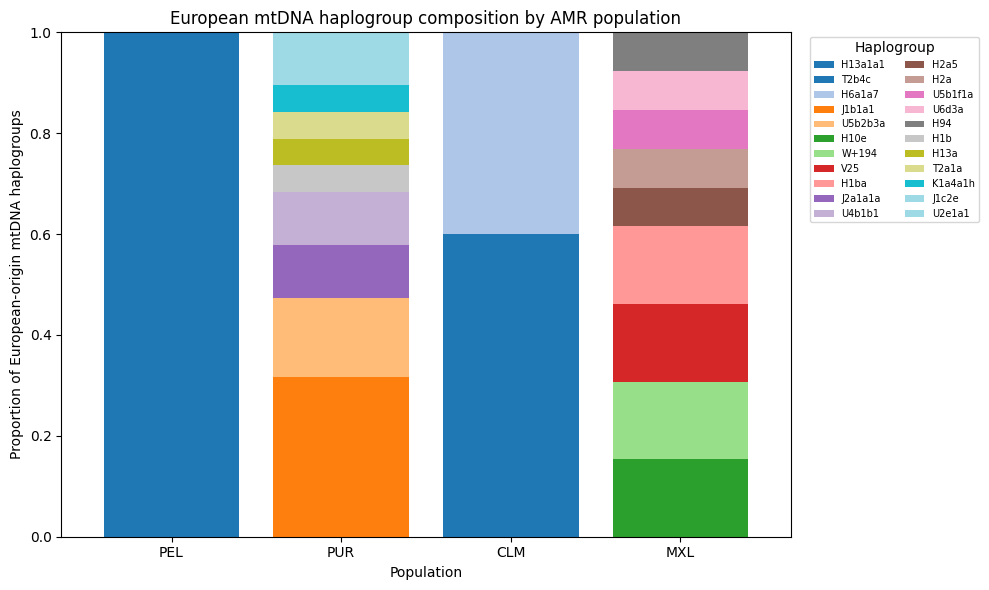

In [99]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import entropy

indo_eur_mito = ['H', 'I', 'J', 'K', 'T', 'V', 'W', 'X', 'U']
amr_mito = {'PEL': mito_pel, 'PUR': mito_pur, 'CLM': mito_clm, 'MXL': mito_mxl}

# ---- filter by macro-letter, KEEP the full haplogroup label ----
eur_haps = {}
for pop, df in amr_mito.items():
    haplo = df['Haplogroup'].astype(str)
    mask = haplo.str[0].isin(indo_eur_mito)
    eur_haps[pop] = haplo[mask].to_numpy()

# ---- proportions per pop (full haplogroup resolution) ----
props = {pop: pd.Series(haps).value_counts(normalize=True)
         for pop, haps in eur_haps.items()}
prop_df = pd.DataFrame(props).fillna(0)
prop_df = prop_df.loc[prop_df.sum(axis=1).sort_values(ascending=False).index]
print(prop_df.round(3))

# ---- stacked bar (full haplogroup composition among European mtDNA) ----
fig, ax = plt.subplots(figsize=(10, 6))
prop_df.T.plot(kind='bar', stacked=True, ax=ax, colormap='tab20', width=0.8)
ax.set_ylabel('Proportion of European-origin mtDNA haplogroups')
ax.set_xlabel('Population')
ax.set_title('European mtDNA haplogroup composition by AMR population')
ax.legend(title='Haplogroup', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7, ncol=2)
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

      n  shannon_H  shannon_H_lo  shannon_H_hi  effective_n  effective_n_lo  \
pop                                                                           
PEL   2      0.000         0.000         0.000        1.000           1.000   
PUR  19      2.059         1.365         2.114        7.840           3.917   
CLM   5      0.673         0.000         0.673        1.960           1.000   
MXL  13      2.138         1.411         2.058        8.486           4.098   

     effective_n_hi  simpson_evenness  simpson_evenness_lo  \
pop                                                          
PEL           1.000             0.000                0.000   
PUR           8.284             0.837                0.659   
CLM           1.960             0.480                0.000   
MXL           7.829             0.876                0.710   

     simpson_evenness_hi  
pop                       
PEL                0.000  
PUR                0.864  
CLM                0.480  
MXL              

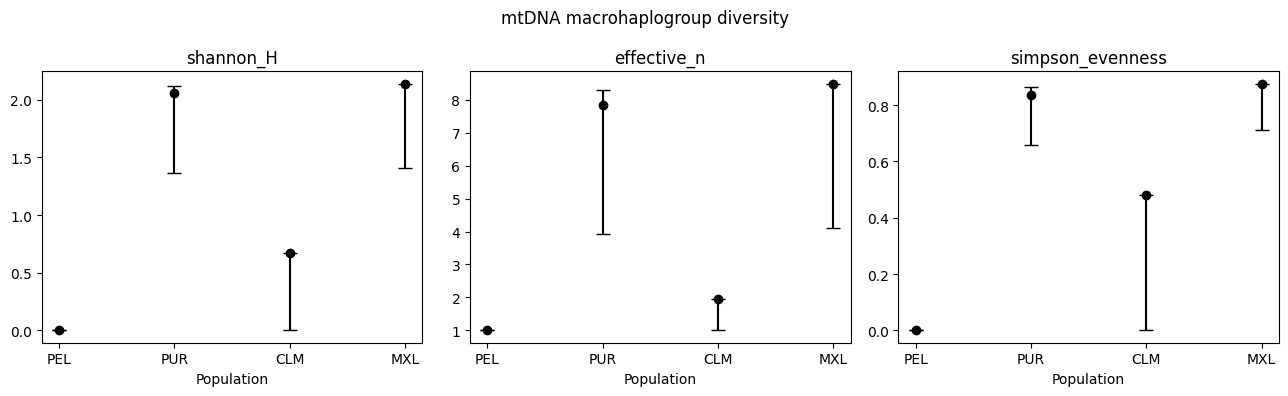

omnibus chi-square (composition): p=4.264e-05
omnibus permutation (shannon_H): p=0.0380
omnibus permutation (effective_n): p=0.9836
omnibus permutation (simpson_evenness): p=0.0402

pairwise (shannon_H):
  PEL vs PUR: Δ=-2.059, p=0.1000, p_adj=0.5999
  PEL vs CLM: Δ=-0.673, p=0.2429, p_adj=1.0000
  PEL vs MXL: Δ=-2.138, p=0.0283, p_adj=0.1698
  PUR vs CLM: Δ=+1.386, p=0.0379, p_adj=0.2274
  PUR vs MXL: Δ=-0.079, p=0.8561, p_adj=1.0000
  CLM vs MXL: Δ=-1.465, p=0.0005, p_adj=0.0030


In [100]:
bootstrap_diversity(eur_haps, title='mtDNA macrohaplogroup diversity',
                    savepath='/users/akuntzle/IBD_archaic_shared/figures/mtDNA_diversity_CI')
significance(eur_haps)